1. Initialize:
   - N_observe = fixed number of particles to observe per step (a+b)
   - B = b_total (total budget)
   - Create reward landscape r(x) with values in [0,1]
   - Initialize CNN f_θ(x) for reward prediction (input: coordinates, output: reward [0,1])
   - Define schedules:
     * a(step) and b(step): top/bottom particle selection (a+b=N_observe, early: small a, large b; late: all a)
     * weight_percentile(step): for sampling particles (early: sample middle weights; late: sample extremes)

2. Baseline Diffusion Model:
   - Define equation: ∂q_t/∂t = -⟨∇, q_t(-f_t + σ_t²∇log q_t)⟩ + (σ_t²/2)Δq_t
   - Define SDE: dx_t = (-f_t(x_t) + σ_t²∇log q_t(x_t))dt + σ_t dW_t
   - Use pretrained score function ∇log q_t(x_t)

3. Feynman-Kac Corrector:
   - Modified SDE: dx_t = σ_t²(∇log q_t(x_t) + (β_t/2)∇r(x_t))dt - f_t(x_t)dt + σ_t dW_t
   - Weight update: dw_t = (∂β_t/∂t)r(x_t)dt - ⟨β_t∇r(x_t), f_t(x_t)⟩dt + ⟨β_t∇r(x_t), (σ_t²/2)∇log q_t(x_t)⟩dt

4. Cold Start (Step 0):
   - Generate N_observe particles using ONLY baseline diffusion (no FKC)
   - Observe ALL particles (get true rewards)
   - Train CNN with (coordinates, rewards) pairs
   - Budget -= N_observe

5. Main Loop (Step 1 onwards, while B > 0):
   a. Generate N particles using FKC with learned reward gradient from CNN (N is fixed)
   b. Calculate weights w for all particles
   c. Epsilon-greedy selection (ε = function of step/total_steps):
      - With probability ε: select k particles randomly
      - With probability 1-ε: select top k particles by weight
      - ε decreases from high (e.g., 0.8) to low (e.g., 0.1) as steps progress
   d. Observe true rewards for selected k particles (k is fixed)
   e. Update CNN with new observations (coordinates → actual reward values)
   f. Calculate success rate
   g. Budget -= k
   h. Visualize results

6. Final visualization:
   - Learned reward landscape (from CNN) vs particles (color by weights)
   - True reward landscape vs observed particles (color by true rewards)
   - Success rate evolution

import

In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, Dict, Any
import optax
from functools import partial

# Set random seed for reproducibility
jax.config.update("jax_enable_x64", True)

reward

In [2]:
def create_reward_landscape(x: jnp.ndarray) -> jnp.ndarray:
    """
    Create a synthetic reward landscape with values in [0,1].
    This is the 'true' reward function that we're trying to learn.
    """
    # BULLETPROOF: Handle any input shape
    original_shape = x.shape
    
    # Ensure we have a 2D array (batch_size, 2)
    if x.ndim == 1:
        x = x.reshape(-1, 2)
        squeeze_output = True
    elif x.ndim == 2:
        squeeze_output = False
    else:
        # Flatten all but last dimension
        x = x.reshape(-1, x.shape[-1])
        squeeze_output = False
    
    
    # Initialize reward as JAX array with correct shape
    reward = jnp.zeros(x.shape[0])
    
    # Add multiple Gaussian peaks
    peaks = [(0.3, 0.7), (0.7, 0.3), (0.5, 0.5)]
    for peak_x, peak_y in peaks:
        # Calculate distance for each particle
        dist = jnp.sqrt((x[:, 0] - peak_x)**2 + (x[:, 1] - peak_y)**2)
        # Add to reward (both should have shape (batch_size,))
        reward = reward + jnp.exp(-dist**2 / 0.1)
    
    # Ensure [0,1] range
    reward = jnp.clip(reward, 0, 1)
    
    # Reshape back to original shape if needed
    if squeeze_output and original_shape == (2,):
        reward = reward.squeeze()
    elif original_shape != x.shape:
        reward = reward.reshape(original_shape[:-1])
    return reward

def reward_landscape_gradient(x: jnp.ndarray) -> jnp.ndarray:
    """Compute gradient of reward landscape using JAX autodiff."""
    if x.ndim == 1:
        return jax.grad(create_reward_landscape)(x)
    else:
        # For batch of particles, use vmap
        grad_fn = jax.grad(create_reward_landscape)
        return jax.vmap(grad_fn)(x)

def create_four_optima_reward_landscape(x: jnp.ndarray) -> jnp.ndarray:
    """
    Create reward landscape with four global optima in four quadrants.
    Peaks at approximately (0.25, 0.25), (0.75, 0.25), (0.25, 0.75), (0.75, 0.75)
    """
    # BULLETPROOF: Handle any input shape
    original_shape = x.shape
    
    # Ensure we have a 2D array (batch_size, 2)
    if x.ndim == 1:
        x = x.reshape(-1, 2)
        squeeze_output = True
    elif x.ndim == 2:
        squeeze_output = False
    else:
        # Flatten all but last dimension
        x = x.reshape(-1, x.shape[-1])
        squeeze_output = False
    
    
    # Initialize reward as JAX array with correct shape
    reward = jnp.zeros(x.shape[0])
    
    # Four equal peaks in four quadrants
    peaks = [(0.25, 0.25), (0.75, 0.25), (0.25, 0.75), (0.75, 0.75)]
    for peak_x, peak_y in peaks:
        dist = jnp.sqrt((x[:, 0] - peak_x)**2 + (x[:, 1] - peak_y)**2)
        reward = reward + jnp.exp(-dist**2 / 0.05)  # Narrower peaks
    
    # FIXED: Don't normalize by 4, let peaks reach higher values
    # reward = reward / 4.0  # Remove this line!
    reward = jnp.clip(reward, 0, 1)  # Just clip to [0,1]
    
    # Reshape back to original shape if needed
    if squeeze_output and original_shape == (2,):
        reward = reward.squeeze()
    elif original_shape != x.shape:
        reward = reward.reshape(original_shape[:-1])
    
    return reward

def four_optima_reward_gradient(x: jnp.ndarray) -> jnp.ndarray:
    """Compute gradient of four optima reward landscape."""
    if x.ndim == 1:
        return jax.grad(create_four_optima_reward_landscape)(x)
    else:
        grad_fn = jax.grad(create_four_optima_reward_landscape)
        return jax.vmap(grad_fn)(x)

baseline diffusion model

In [3]:
def baseline_score_function(x: jnp.ndarray, t: float) -> jnp.ndarray:
    """
    Pretrained score function for baseline diffusion.
    This is a simple Gaussian score function for demonstration.
    """
    # Simple Gaussian target distribution
    mean = jnp.array([0.5, 0.5])
    sigma = 0.3
    
    # Handle both single particle and batch
    if x.ndim == 1:
        score = -(x - mean) / (sigma**2)
    else:  # Batch of particles
        score = -(x - mean[None, :]) / (sigma**2)
    
    return score

def baseline_drift(x: jnp.ndarray, t: float) -> jnp.ndarray:
    """Deterministic drift term f_t(x_t) for baseline diffusion."""
    # Return zeros with the same shape as input
    return jnp.zeros_like(x)

def diffusion_coefficient(t: float) -> float:
    """Time-dependent diffusion coefficient σ_t."""
    return 0.1 * (1 - t)  # Decreases from 0.1 to 0

def baseline_sde_step(x: jnp.ndarray, t: float, dt: float, key: jnp.ndarray) -> jnp.ndarray:
    """
    Single step of baseline SDE: dx_t = (-f_t(x_t) + σ_t²∇log q_t(x_t))dt + σ_t dW_t
    """
    sigma_t = diffusion_coefficient(t)
    score = baseline_score_function(x, t)
    drift = -baseline_drift(x, t) + sigma_t**2 * score
    noise = sigma_t * random.normal(key, x.shape)
    
    # Use absolute value of dt for noise scaling since we go backwards in time
    return x + drift * dt + noise * jnp.sqrt(jnp.abs(dt))  # FIXED: use abs(dt)

feynman-kac corrector

In [4]:
def feynman_kac_sde_step(x: jnp.ndarray, w: jnp.ndarray, t: float, dt: float, 
                         reward_grad_fn, beta_t: float, key: jnp.ndarray, 
                         network, network_params) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Single step of Feynman-Kac corrected SDE with numerical stability.
    
    Equation 29: dx_t = σ_t²(∇log q_t(x_t) + (β_t/2)∇r(x_t))dt - f_t(x_t)dt + σ_t dW_t
    Equation 30: dw_t = (∂β_t/∂t)r(x_t)dt - ⟨β_t∇r(x_t), f_t(x_t)⟩dt + ⟨β_t∇r(x_t), (σ_t²/2)∇log q_t(x_t)⟩dt
    
    NOTE: When integrating backwards (dt < 0), we use |dt| for weight updates to ensure
    high rewards increase weights.
    """
    sigma_t = diffusion_coefficient(t)
    score = baseline_score_function(x, t)
    reward_grad = reward_grad_fn(x)
    
    # Equation 29: Update particle position
    drift = sigma_t**2 * (score + (beta_t / 2) * reward_grad) - baseline_drift(x, t)
    noise = sigma_t * random.normal(key, x.shape)
    x_new = x + drift * dt + noise * jnp.sqrt(jnp.abs(dt))
    
    # Equation 30: Update weight with numerical stability
    # CRITICAL FIX: Use abs(dt) for weight updates when going backwards in time
    predicted_reward = network['forward'](network_params, x)
    beta_dot = 1.0  # ∂β_t/∂t = 1 (constant beta_t)
    
    dt_abs = jnp.abs(dt)  # FIX: Use absolute value of dt for weight updates
    
    # Handle vectorized operations for batch of particles
    if x.ndim == 2:  # Batch of particles
        # Term 1: (∂β_t/∂t)r(x_t)|dt|  -- FIXED: Use dt_abs
        term1 = beta_dot * predicted_reward * dt_abs
        
        # Term 2: -⟨β_t∇r(x_t), f_t(x_t)⟩|dt|  -- FIXED: Use dt_abs
        f_t = baseline_drift(x, t)
        term2 = -jnp.sum(beta_t * reward_grad * f_t, axis=1) * dt_abs
        
        # Term 3: +⟨β_t∇r(x_t), (σ_t²/2)∇log q_t(x_t)⟩|dt|  -- FIXED: Use dt_abs
        term3 = jnp.sum(beta_t * reward_grad * (sigma_t**2 / 2) * score, axis=1) * dt_abs
        
        # Combine all terms
        dw = term1 + term2 + term3
        
    else:  # Single particle
        # Term 1: (∂β_t/∂t)r(x_t)|dt|  -- FIXED: Use dt_abs
        term1 = beta_dot * predicted_reward * dt_abs
        
        # Term 2: -⟨β_t∇r(x_t), f_t(x_t)⟩|dt|  -- FIXED: Use dt_abs
        f_t = baseline_drift(x, t)
        term2 = -jnp.dot(beta_t * reward_grad, f_t) * dt_abs
        
        # Term 3: +⟨β_t∇r(x_t), (σ_t²/2)∇log q_t(x_t)⟩|dt|  -- FIXED: Use dt_abs
        term3 = jnp.dot(beta_t * reward_grad, (sigma_t**2 / 2) * score) * dt_abs
        
        # Combine all terms
        dw = term1 + term2 + term3
    
    # Add numerical stability to weight updates
    # Clip dw to prevent extreme changes
    dw = jnp.clip(dw, -0.1, 0.1)
    
    # Update weights
    w_new = w + dw
    
    # Ensure weights stay positive and bounded
    w_new = jnp.clip(w_new, 0.1, 10.0)
    
    return x_new, w_new

def run_fkc_simulation(particles: jnp.ndarray, weights: jnp.ndarray, 
                      reward_grad_fn, beta_t: float, n_steps: int, key: jnp.ndarray,
                      network, network_params) -> Tuple[jnp.ndarray, jnp.ndarray]:  # Add network params
    """Run FKC simulation from t=1 to t=0."""
    dt = -1.0 / n_steps  # Negative because we go from t=1 to t=0
    
    for i in range(n_steps):
        t = 1.0 + i * dt
        key, subkey = random.split(key)
        particles, weights = feynman_kac_sde_step(particles, weights, t, dt, 
                                                reward_grad_fn, beta_t, subkey, 
                                                network, network_params)
        
        # Check for numerical issues and fix immediately
        if jnp.any(jnp.isnan(weights)) or jnp.any(jnp.isinf(weights)):
            weights = jnp.where(jnp.isnan(weights) | jnp.isinf(weights), 1.0, weights)
        
        # Also check for NaN particles
        if jnp.any(jnp.isnan(particles)) or jnp.any(jnp.isinf(particles)):
            print(f"  WARNING: NaN particles detected at step {i}, clipping...")
            particles = jnp.where(jnp.isnan(particles) | jnp.isinf(particles), 
                                jnp.clip(particles, 0, 1), particles)
    
    return particles, weights

reward learning neural network

In [5]:
def create_cnn_reward_network():
    """
    Create a CNN for reward prediction that treats 2D coordinates as spatial features.
    """
    def init_fn(key):
        """Initialize CNN parameters."""
        params = {}
        
        # Feature expansion layer: 2 -> 32
        key, subkey = random.split(key)
        params['expand_W'] = random.normal(subkey, (2, 32)) * 0.1
        params['expand_b'] = jnp.zeros(32)
        
        # Conv layers (we'll simulate with dense layers on feature representations)
        key, subkey = random.split(key)
        params['conv1_W'] = random.normal(subkey, (32, 64)) * 0.1
        params['conv1_b'] = jnp.zeros(64)
        
        key, subkey = random.split(key)
        params['conv2_W'] = random.normal(subkey, (64, 64)) * 0.1
        params['conv2_b'] = jnp.zeros(64)
        
        # Fully connected layers
        key, subkey = random.split(key)
        params['fc1_W'] = random.normal(subkey, (64, 32)) * 0.1
        params['fc1_b'] = jnp.zeros(32)
        
        key, subkey = random.split(key)
        params['fc2_W'] = random.normal(subkey, (32, 1)) * 0.1
        params['fc2_b'] = jnp.zeros(1)
        
        return params
    
    def forward(params, x):
        """Forward pass through CNN."""
        # Handle both single particle and batch
        if x.ndim == 1:
            x = x.reshape(1, -1)
            squeeze_output = True
        else:
            squeeze_output = False
        
        # Feature expansion
        h = jnp.dot(x, params['expand_W']) + params['expand_b']
        h = jax.nn.relu(h)
        
        # Conv-like layer 1
        h = jnp.dot(h, params['conv1_W']) + params['conv1_b']
        h = jax.nn.relu(h)
        
        # Conv-like layer 2
        h = jnp.dot(h, params['conv2_W']) + params['conv2_b']
        h = jax.nn.relu(h)
        
        # Fully connected layer 1
        h = jnp.dot(h, params['fc1_W']) + params['fc1_b']
        h = jax.nn.relu(h)
        
        # Output layer: predict actual reward value [0,1]
        h = jnp.dot(h, params['fc2_W']) + params['fc2_b']
        h = jax.nn.sigmoid(h)  # Output in [0,1]
        
        
        # CRITICAL FIX: Ensure output is 1D for batch inputs
        if h.ndim > 1 and h.shape[-1] == 1:
            h = h.squeeze(-1)  # Remove the last dimension if it's 1
        
        if squeeze_output:
            h = h.squeeze()
        
        
        return h
    
    return {'init': init_fn, 'forward': forward}

def update_network(network, params, optimizer, opt_state, x_batch, y_batch):
    """Update neural network parameters using observed rewards."""
    def loss_fn(params):
        predictions = network['forward'](params, x_batch)
        
        # Ensure shapes match
        if predictions.shape != y_batch.shape:
            if predictions.ndim > y_batch.ndim:
                # Remove extra dimensions
                while predictions.ndim > y_batch.ndim:
                    predictions = predictions.squeeze(-1)
            elif predictions.ndim < y_batch.ndim:
                # Add missing dimensions
                while predictions.ndim < y_batch.ndim:
                    predictions = predictions.unsqueeze(-1)
        
        # MSE loss on actual reward values [0,1]
        return jnp.mean((predictions - y_batch)**2)
    
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, loss

def reward_network_gradient(network, params, x):
    """Compute gradient of reward network using JAX autodiff with numerical stability."""
    # For vectorized inputs, we need to compute gradients for each particle
    if x.ndim == 2:  # Batch of particles
        # Use vmap to vectorize the gradient computation
        grad_fn = jax.grad(lambda single_x: network['forward'](params, single_x))
        grad = jax.vmap(grad_fn)(x)
    else:  # Single particle
        grad = jax.grad(lambda single_x: network['forward'](params, single_x))(x)
    
    # Add numerical stability: clip gradients to prevent extreme values
    grad = jnp.clip(grad, -10.0, 10.0)
    
    # Check for NaN values and replace with zeros
    grad = jnp.where(jnp.isnan(grad) | jnp.isinf(grad), 0.0, grad)
    
    return grad

main algorithm

In [6]:
def get_epsilon_schedule(step, total_steps):
    """
    Epsilon schedule for epsilon-greedy selection.
    High epsilon early (more exploration), low epsilon late (more exploitation).
    
    Args:
        step: Current step (0-indexed)
        total_steps: Total number of steps
    
    Returns:
        epsilon: Probability of random selection [0,1]
    """
    progress = step / max(total_steps - 1, 1)
    # Linear decay from 0.8 to 0.1
    epsilon = 0.8 - 0.7 * progress
    return epsilon


def budget_constrained_diffusion(k_observe: int, B: int, 
                                n_particles: int = 200,
                                n_steps: int = 100, 
                                reward_fn = None,
                                network = None,
                                network_params = None,
                                opt_state = None):
    """
    Main algorithm for budget-constrained diffusion with Feynman-Kac correctors.
    
    Args:
        k_observe: Fixed number of particles to observe per step (k)
        B: Total budget (number of observations)
        n_particles: Fixed number of particles to generate per step (N)
        n_steps: Number of time steps in FKC simulation
        reward_fn: Reward function to use
        network: Pre-trained network (optional, for continuing training)
        network_params: Pre-trained network parameters (optional)
        opt_state: Pre-trained optimizer state (optional)
    """
    if reward_fn is None:
        raise ValueError("Must provide a reward_fn")
    
    if k_observe > n_particles:
        raise ValueError("k_observe must be <= n_particles")
    
    # Initialize
    key = random.PRNGKey(42)
    
    # NEW: Use existing network or create new one
    if network is None:
        network = create_cnn_reward_network()
        key, subkey = random.split(key)
        network_params = network['init'](subkey)
        optimizer = optax.adam(learning_rate=0.01)
        opt_state = optimizer.init(network_params)
        print("  Created new neural network")
    else:
        optimizer = optax.adam(learning_rate=0.01)
        if opt_state is None:
            opt_state = optimizer.init(network_params)
        print("  Using pre-trained neural network (continuing training)")
    
    # Storage for results
    all_particles = []
    all_weights = []
    all_observed_particles = []
    all_observed_rewards = []
    success_rates = []
    epsilon_history = []
    selection_method_history = []
    num_random_selected = []
    num_topk_selected = []
    
    # Estimate total steps
    total_steps = B // k_observe
    step_count = 0
    
    # === COLD START (Step 0) ===
    print(f"Step {step_count} [COLD START], Budget remaining: {B}")
    
    # Generate k_observe particles using ONLY baseline diffusion (no FKC)
    key, subkey = random.split(key)
    particles = random.uniform(subkey, (k_observe, 2))
    
    # Run baseline diffusion
    dt = -1.0 / n_steps
    for i in range(n_steps):
        t = 1.0 + i * dt
        key, subkey = random.split(key)
        particles = baseline_sde_step(particles, t, dt, subkey)
    
    # Clip particles to [0,1]
    particles = jnp.clip(particles, 0, 1)
    
    # Observe ALL particles
    observed_particles = particles
    observed_rewards = reward_fn(observed_particles)
    
    # Train CNN with initial observations
    for epoch in range(50):
        network_params, opt_state, loss = update_network(
            network, network_params, optimizer, opt_state,
            observed_particles, observed_rewards
        )
    
    # Calculate success rate
    success_rate = jnp.mean((observed_rewards > 0.7).astype(float))
    success_rates.append(success_rate)
    
    # Store results
    all_particles.append(particles)
    all_weights.append(jnp.ones(len(particles)))
    all_observed_particles.append(observed_particles)
    all_observed_rewards.append(observed_rewards)
    
    # Update budget
    B -= k_observe
    step_count += 1
    
    # Visualize cold start
    visualize_step(step_count, particles, jnp.ones(len(particles)), observed_particles, 
                  observed_rewards, success_rates, network, network_params, reward_fn)
    
    # === MAIN LOOP (Step 1 onwards) ===
    while B > 0:
        print(f"Step {step_count}, Budget remaining: {B}")
        
        # Generate N particles (FIXED NUMBER) using FKC with learned reward
        key, subkey = random.split(key)
        particles = random.uniform(subkey, (n_particles, 2))
        weights = jnp.zeros(n_particles)
        
        # Create reward gradient function using CNN
        def reward_grad_fn(x):
            return reward_network_gradient(network, network_params, x)
        
        # Run FKC simulation
        particles, weights = run_fkc_simulation(
            particles, weights, 
            reward_grad_fn,
            beta_t=1.0,
            n_steps=n_steps,
            key=subkey,
            network=network,
            network_params=network_params
        )
        
        # Clip particles to [0,1]
        particles = jnp.clip(particles, 0, 1)
        
        # Ensure weights are valid
        valid_weights = ~jnp.isnan(weights) & ~jnp.isinf(weights)
        weights = jnp.where(valid_weights, weights, 1.0)
        
        # === CORRECTED EPSILON-GREEDY SELECTION ===
        # Calculate epsilon for this step
        epsilon = get_epsilon_schedule(step_count - 1, total_steps)
        epsilon_history.append(epsilon)
        
        # Calculate how many particles to select randomly vs top-k
        n_random = int(jnp.round(epsilon * k_observe))
        n_topk = k_observe - n_random
        
        num_random_selected.append(n_random)
        num_topk_selected.append(n_topk)
        
        # Select n_topk particles from top weights
        if n_topk > 0:
            sorted_indices = jnp.argsort(weights)
            topk_indices = sorted_indices[-n_topk:]  # Top n_topk highest weights
        else:
            topk_indices = jnp.array([], dtype=jnp.int32)
        
        # Select n_random particles randomly from remaining particles
        if n_random > 0:
            # Create mask for particles not in top-k
            all_indices = jnp.arange(n_particles)
            if n_topk > 0:
                # Exclude the top-k indices from random selection
                mask = jnp.ones(n_particles, dtype=bool)
                mask = mask.at[topk_indices].set(False)
                remaining_indices = all_indices[mask]
            else:
                remaining_indices = all_indices
            
            # Randomly sample from remaining
            key, subkey = random.split(key)
            random_indices = random.choice(subkey, remaining_indices, (n_random,), replace=False)
        else:
            random_indices = jnp.array([], dtype=jnp.int32)
        
        # Combine indices
        observe_indices = jnp.concatenate([topk_indices, random_indices])
        
        # Track which method was dominant
        if n_random > n_topk:
            selection_method_history.append('random')
        else:
            selection_method_history.append('top-k')
        
        # Print selection info
        print(f"  Epsilon={epsilon:.3f} -> Selecting {n_topk} top-k + {n_random} random particles")
        if n_topk > 0:
            selected_topk_weights = weights[topk_indices]
            print(f"    Top-k weight range: [{jnp.min(selected_topk_weights):.3f}, {jnp.max(selected_topk_weights):.3f}]")
        if n_random > 0:
            selected_random_weights = weights[random_indices]
            print(f"    Random weight range: [{jnp.min(selected_random_weights):.3f}, {jnp.max(selected_random_weights):.3f}]")
        print(f"    All particles weight range: [{jnp.min(weights):.3f}, {jnp.max(weights):.3f}]")
        
        # Observe true rewards (FIXED NUMBER k_observe)
        observed_particles = particles[observe_indices]
        observed_rewards = reward_fn(observed_particles)
        
        # Calculate success rate
        success_rate = jnp.mean((observed_rewards > 0.7).astype(float))
        success_rates.append(success_rate)
        
        # Update CNN with new observations (accumulate training)
        print(f"  Training CNN on {len(observed_particles)} new observations...")
        for epoch in range(50):
            network_params, opt_state, loss = update_network(
                network, network_params, optimizer, opt_state,
                observed_particles, observed_rewards
            )
        
        # Store results
        all_particles.append(particles)
        all_weights.append(weights)
        all_observed_particles.append(observed_particles)
        all_observed_rewards.append(observed_rewards)
        
        # Update budget (always use exactly k_observe)
        n_to_observe = min(k_observe, B)
        B -= n_to_observe
        step_count += 1
        
        # Visualize
        visualize_step(step_count, particles, weights, observed_particles, 
                      observed_rewards, success_rates, network, network_params, reward_fn)
    
    # Return results AND trained network
    return (all_particles, all_weights, all_observed_particles, all_observed_rewards, 
            success_rates, network, network_params, opt_state, 
            epsilon_history, selection_method_history, num_random_selected, num_topk_selected)

visualization

In [7]:
def visualize_step(step: int, particles: jnp.ndarray, weights: jnp.ndarray, 
                  observed_particles: jnp.ndarray, observed_rewards: jnp.ndarray,
                  success_rates: list, network: Dict, network_params: Dict,
                  reward_fn):
    """
    Visualize results for current step.
    
    Plot 1: CNN learned reward landscape + all generated particles (colored by weight) + selected particles (circled)
    Plot 2: True reward landscape + observed particles (colored by actual reward - continuous)
    Plot 3: Success rate evolution
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Create grid for landscape visualization
    x_grid = jnp.linspace(0, 1, 100)
    y_grid = jnp.linspace(0, 1, 100)
    X, Y = jnp.meshgrid(x_grid, y_grid)
    grid_points = jnp.stack([X.ravel(), Y.ravel()], axis=1)
    
    # === PLOT 1: CNN Learned Reward + All Particles (colored by weight) + Selected Particles (circled) ===
    # Get CNN learned rewards for grid
    learned_rewards = network['forward'](network_params, grid_points)
    learned_rewards = learned_rewards.reshape(X.shape)
    
    # Plot learned reward landscape
    im1 = axes[0].contourf(X, Y, learned_rewards, levels=20, cmap='viridis', alpha=0.4)
    plt.colorbar(im1, ax=axes[0], label='Learned Reward')
    
    # Plot all generated particles colored by their weights
    valid_particles = ~jnp.isnan(particles).any(axis=1)
    valid_weights = weights[valid_particles]
    valid_particles_coords = particles[valid_particles]
    
    if len(valid_particles_coords) > 0:
        # Use a colormap to show weight distribution
        scatter_all = axes[0].scatter(
            valid_particles_coords[:, 0], 
            valid_particles_coords[:, 1],
            c=valid_weights,  # Color by weight
            cmap='plasma',  # Different colormap from landscape
            s=30, 
            alpha=0.6,
            vmin=jnp.min(valid_weights),
            vmax=jnp.max(valid_weights),
            edgecolors='none',
            label=f'All particles (n={len(valid_particles_coords)})'
        )
        # Add colorbar for particle weights
        cbar_weights = plt.colorbar(scatter_all, ax=axes[0], label='Particle Weight', 
                                    orientation='horizontal', pad=0.05, aspect=30)
    
    # Circle the selected/observed particles with thick black edges
    if len(observed_particles) > 0:
        axes[0].scatter(
            observed_particles[:, 0], 
            observed_particles[:, 1],
            s=150,  # Larger size
            facecolors='none',  # Transparent fill
            edgecolors='red',  # Red edge
            linewidths=2.5,  # Thick edge
            marker='o',
            label=f'Selected (n={len(observed_particles)})'
        )
    
    axes[0].set_title(f'Step {step}: CNN Learned Reward\n+ All Particles (colored by weight) + Selected (red circles)')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    
    # === PLOT 2: True Reward + Observed Particles (color by actual reward - continuous) ===
    # Get true rewards for grid
    true_rewards = reward_fn(grid_points)
    true_rewards = true_rewards.reshape(X.shape)
    
    # Plot true reward landscape
    im2 = axes[1].contourf(X, Y, true_rewards, levels=20, cmap='viridis', alpha=0.6)
    plt.colorbar(im2, ax=axes[1], label='True Reward')
    
    # Plot observed particles colored by their ACTUAL REWARD VALUE (continuous)
    if len(observed_particles) > 0:
        scatter = axes[1].scatter(
            observed_particles[:, 0], 
            observed_particles[:, 1],
            c=observed_rewards,  # Color by actual reward value
            cmap='RdYlGn',  # Red (low) to Yellow to Green (high)
            s=100, 
            alpha=0.9, 
            marker='o', 
            edgecolors='black', 
            linewidths=1.5,
            vmin=0, 
            vmax=1,  # Reward range [0,1]
            label=f'Observed (n={len(observed_particles)})'
        )
        # Add colorbar for observed rewards
        cbar_scatter = plt.colorbar(scatter, ax=axes[1], label='Observed Reward Value', 
                                   orientation='horizontal', pad=0.1, aspect=30)
    
    axes[1].set_title(f'Step {step}: True Reward Landscape\n+ Observed Particles (Colored by Actual Reward)')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    
    # === PLOT 3: Success Rate Evolution ===
    axes[2].plot(range(1, len(success_rates) + 1), success_rates, 'b-o', linewidth=2, markersize=6)
    axes[2].set_title('Success Rate Evolution')
    axes[2].set_xlabel('Step')
    axes[2].set_ylabel('Success Rate')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(0, 1)
    axes[2].axhline(y=0.7, color='r', linestyle='--', alpha=0.5, label='Target (0.7)')
    axes[2].legend(loc='lower right', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print vital statistics only
    if len(observed_particles) > 0:
        success_threshold = 0.7
        n_success = jnp.sum(observed_rewards > success_threshold)
        avg_reward = jnp.mean(observed_rewards)
        
        print(f"Step {step}: Observed {len(observed_particles)} particles | "
              f"Avg Reward: {avg_reward:.3f} | "
              f"Success: {n_success}/{len(observed_particles)} ({success_rates[-1]:.1%})")

In [8]:
def visualize_epsilon_and_selection(epsilon_history, selection_method_history, 
                                   num_random_selected, num_topk_selected, k_observe):
    """
    Visualize epsilon schedule and selection method distribution.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    steps = range(1, len(epsilon_history) + 1)
    
    # Plot 1: Epsilon decay over time
    axes[0, 0].plot(steps, epsilon_history, 'b-o', linewidth=2, markersize=6)
    axes[0, 0].set_title('Epsilon Schedule (Probability of Random Selection)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Step', fontsize=12)
    axes[0, 0].set_ylabel('Epsilon', fontsize=12)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 threshold')
    axes[0, 0].legend()
    
    # Plot 2: Number of particles selected by each method (stacked bar)
    axes[0, 1].bar(steps, num_random_selected, color='orange', alpha=0.7, label='Random', edgecolor='black', linewidth=0.5)
    axes[0, 1].bar(steps, num_topk_selected, bottom=num_random_selected, color='green', alpha=0.7, label='Top-k', edgecolor='black', linewidth=0.5)
    axes[0, 1].set_title(f'Particles Selected by Method (Total k={k_observe})', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Step', fontsize=12)
    axes[0, 1].set_ylabel('Number of Particles', fontsize=12)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    axes[0, 1].set_ylim(0, k_observe * 1.1)
    
    # Plot 3: Proportion of each selection method
    proportions_random = np.array(num_random_selected) / k_observe
    proportions_topk = np.array(num_topk_selected) / k_observe
    
    axes[1, 0].plot(steps, proportions_random, 'o-', color='orange', linewidth=2, markersize=6, label='Random')
    axes[1, 0].plot(steps, proportions_topk, 's-', color='green', linewidth=2, markersize=6, label='Top-k')
    axes[1, 0].set_title('Proportion of Selection Methods', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Step', fontsize=12)
    axes[1, 0].set_ylabel('Proportion', fontsize=12)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim(0, 1)
    
    # Plot 4: Cumulative count
    cumsum_random = np.cumsum(num_random_selected)
    cumsum_topk = np.cumsum(num_topk_selected)
    
    axes[1, 1].plot(steps, cumsum_random, 'o-', color='orange', linewidth=2, markersize=6, label='Random')
    axes[1, 1].plot(steps, cumsum_topk, 's-', color='green', linewidth=2, markersize=6, label='Top-k')
    axes[1, 1].set_title('Cumulative Particles Selected', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Step', fontsize=12)
    axes[1, 1].set_ylabel('Cumulative Count', fontsize=12)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*80)
    print("EPSILON-GREEDY SELECTION SUMMARY")
    print("="*80)
    total_steps = len(epsilon_history)
    total_random = sum(num_random_selected)
    total_topk = sum(num_topk_selected)
    total_particles = total_random + total_topk
    
    print(f"Total steps (excluding cold start): {total_steps}")
    print(f"Total particles observed: {total_particles}")
    print(f"Particles selected RANDOMLY: {total_random} ({100*total_random/total_particles:.1f}%)")
    print(f"Particles selected TOP-K: {total_topk} ({100*total_topk/total_particles:.1f}%)")
    print(f"\nEpsilon range: [{min(epsilon_history):.3f}, {max(epsilon_history):.3f}]")
    print(f"Final epsilon: {epsilon_history[-1]:.3f}")
    print(f"Average particles per step - Random: {total_random/total_steps:.1f}, Top-k: {total_topk/total_steps:.1f}")
    print("="*80 + "\n")

run

  Created new neural network
Step 0 [COLD START], Budget remaining: 500


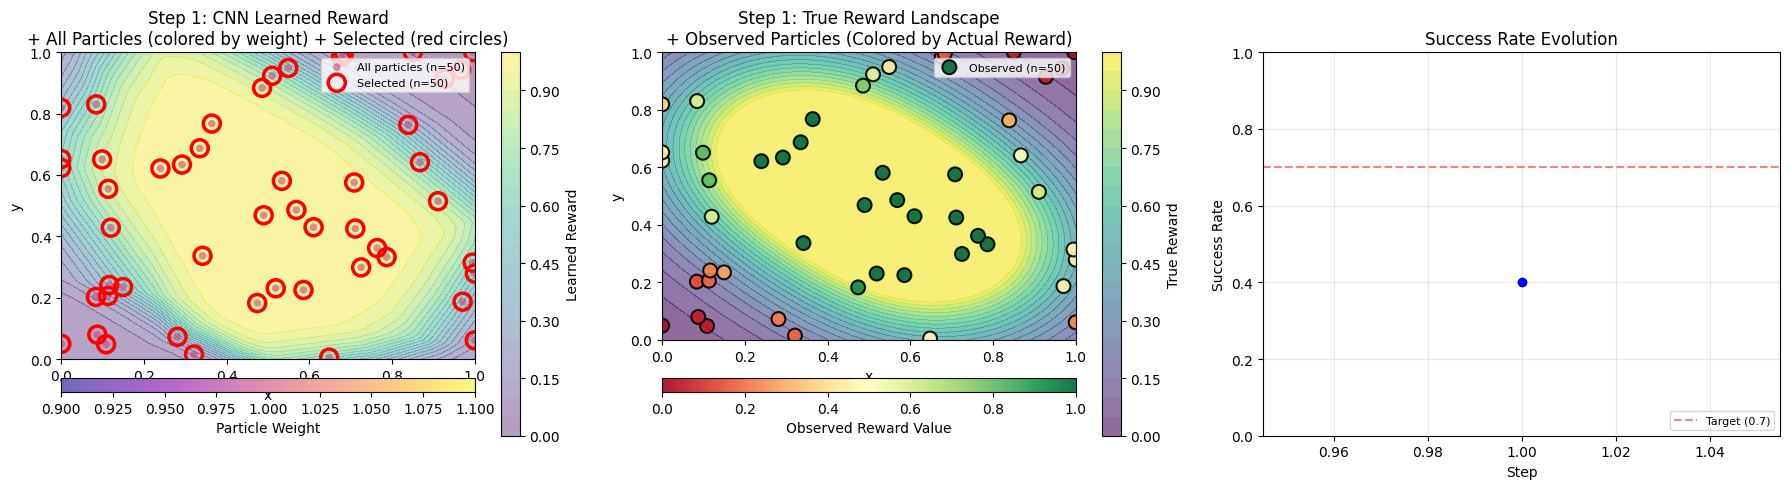

Step 1: Observed 50 particles | Avg Reward: 0.565 | Success: 20/50 (40.0%)
Step 1, Budget remaining: 450
  Epsilon=0.800 -> Selecting 10 top-k + 40 random particles
    Top-k weight range: [1.088, 1.089]
    Random weight range: [0.141, 1.088]
    All particles weight range: [0.141, 1.089]
  Training CNN on 50 new observations...


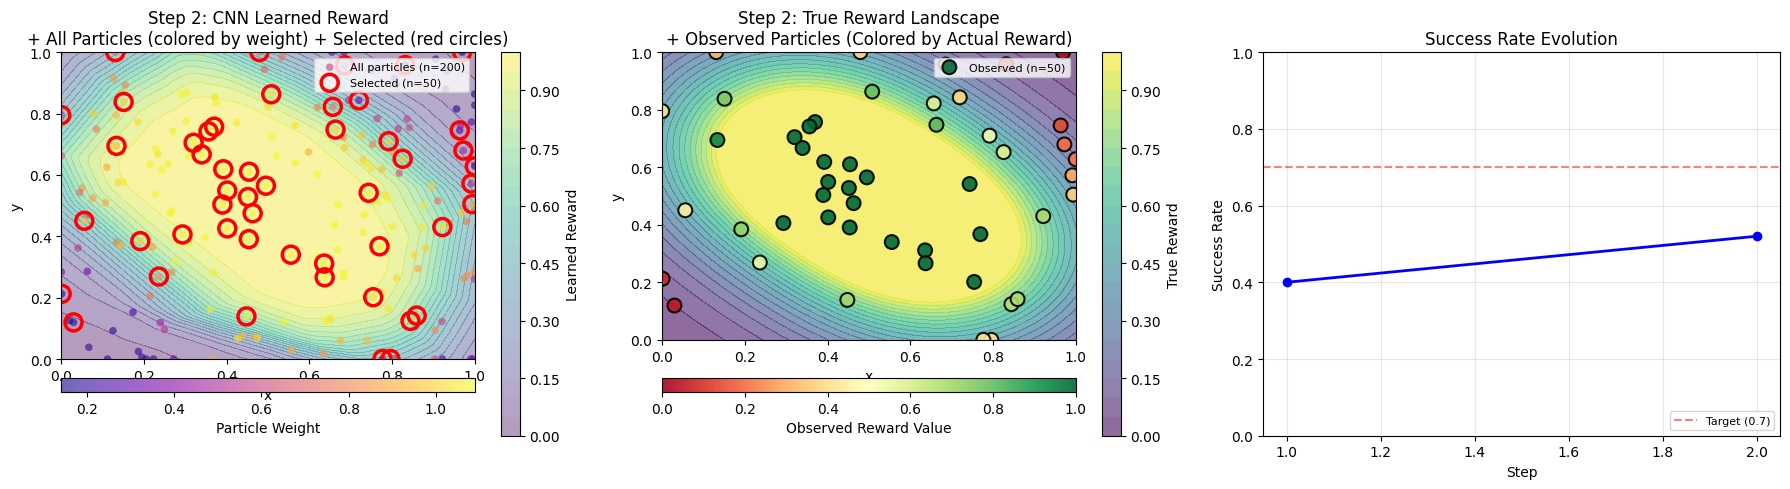

Step 2: Observed 50 particles | Avg Reward: 0.670 | Success: 26/50 (52.0%)
Step 2, Budget remaining: 400
  Epsilon=0.722 -> Selecting 14 top-k + 36 random particles
    Top-k weight range: [1.085, 1.087]
    Random weight range: [0.144, 1.084]
    All particles weight range: [0.137, 1.087]
  Training CNN on 50 new observations...


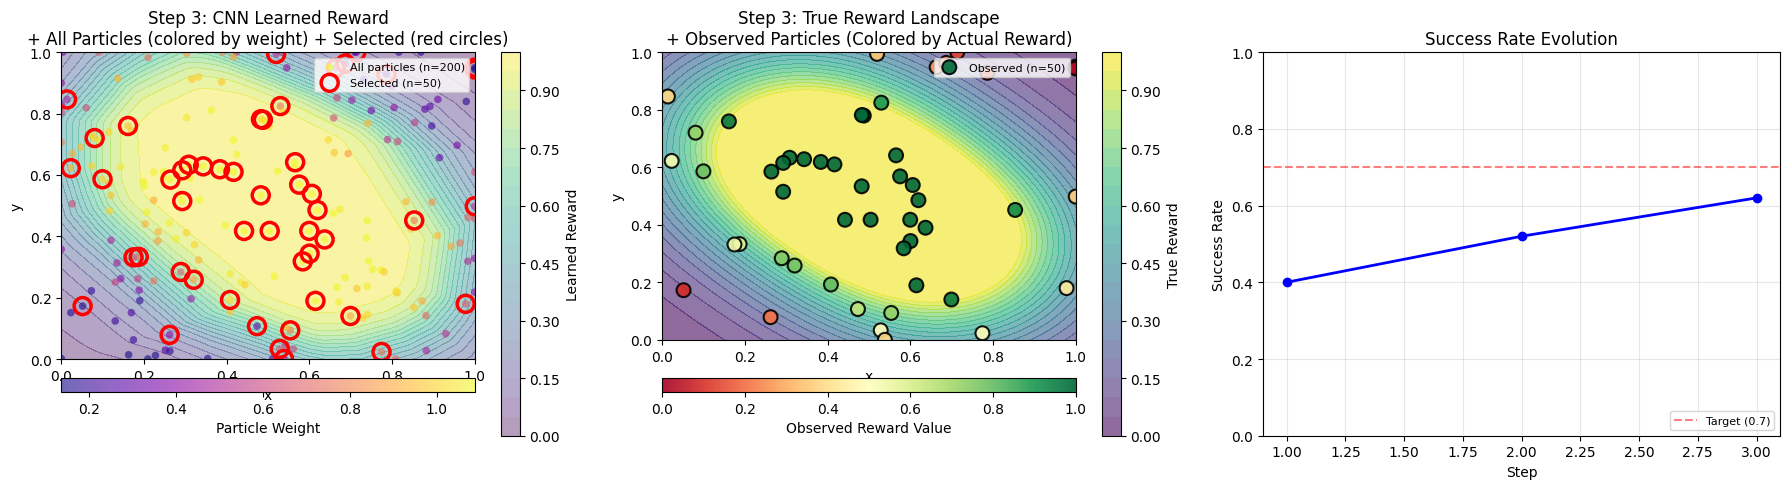

Step 3: Observed 50 particles | Avg Reward: 0.713 | Success: 31/50 (62.0%)
Step 3, Budget remaining: 350
  Epsilon=0.644 -> Selecting 18 top-k + 32 random particles
    Top-k weight range: [1.086, 1.088]
    Random weight range: [0.131, 1.086]
    All particles weight range: [0.131, 1.088]
  Training CNN on 50 new observations...


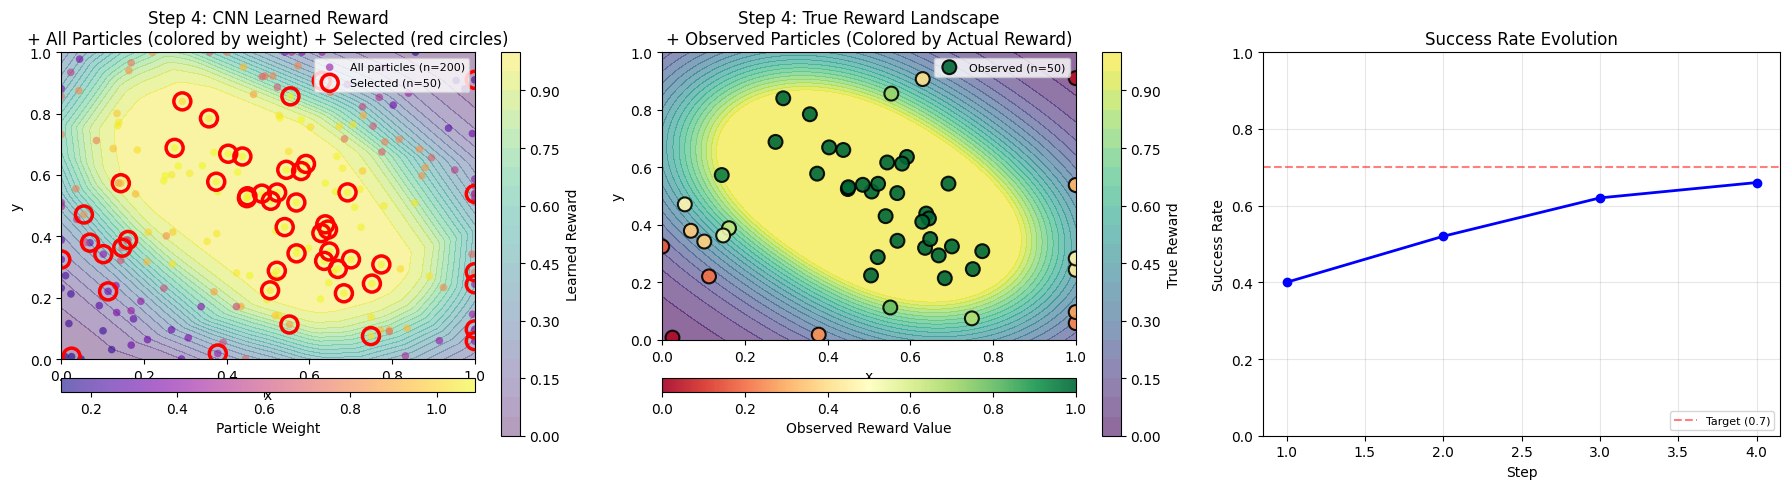

Step 4: Observed 50 particles | Avg Reward: 0.767 | Success: 33/50 (66.0%)
Step 4, Budget remaining: 300
  Epsilon=0.567 -> Selecting 22 top-k + 28 random particles
    Top-k weight range: [1.082, 1.088]
    Random weight range: [0.158, 1.072]
    All particles weight range: [0.122, 1.088]
  Training CNN on 50 new observations...


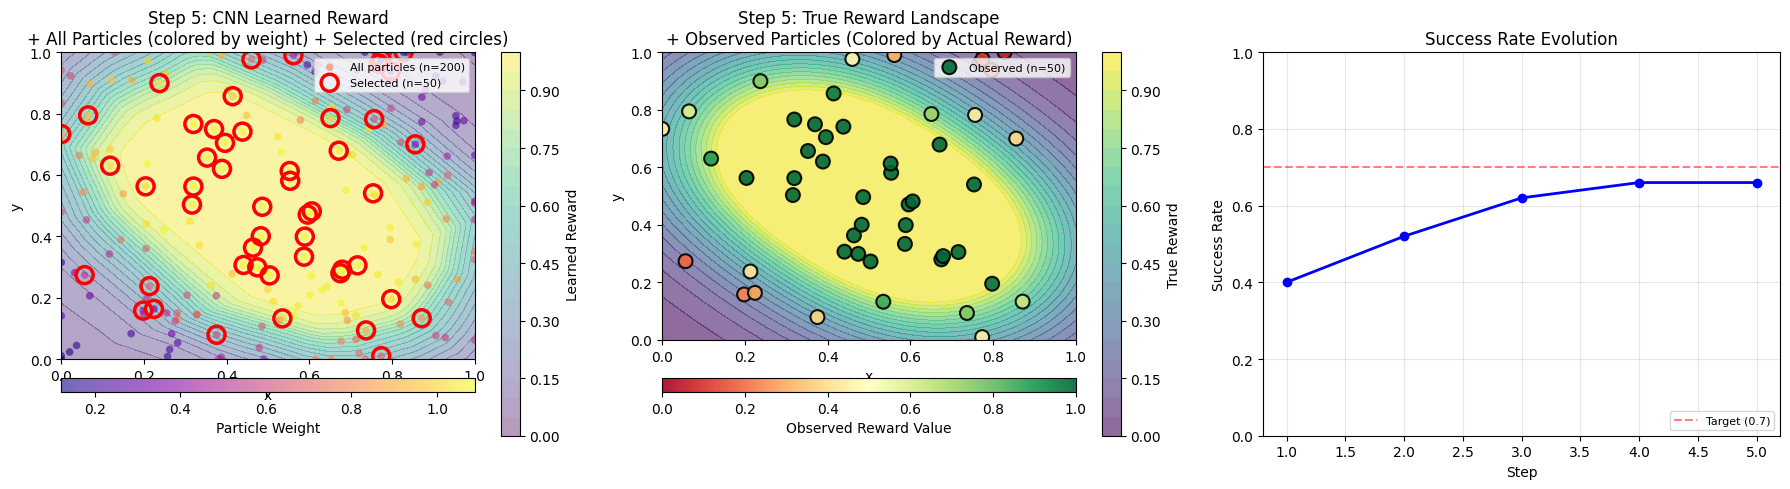

Step 5: Observed 50 particles | Avg Reward: 0.752 | Success: 33/50 (66.0%)
Step 5, Budget remaining: 250
  Epsilon=0.489 -> Selecting 26 top-k + 24 random particles
    Top-k weight range: [1.086, 1.090]
    Random weight range: [0.191, 1.086]
    All particles weight range: [0.157, 1.090]
  Training CNN on 50 new observations...


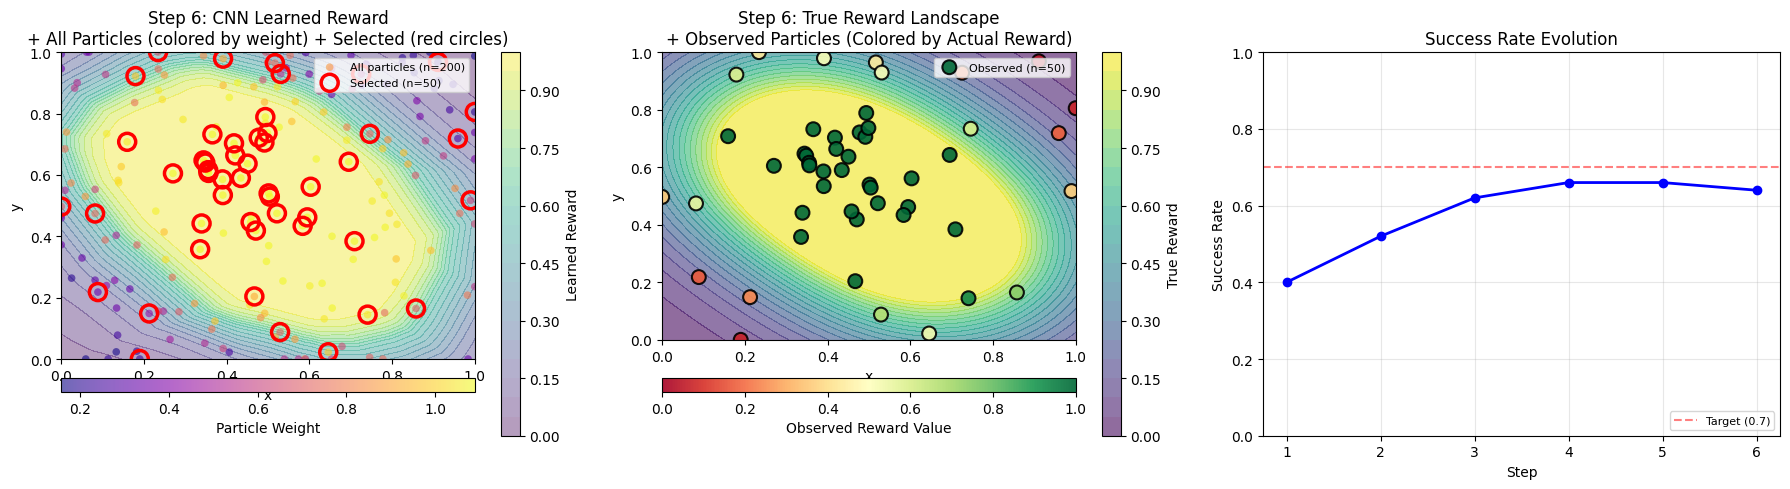

Step 6: Observed 50 particles | Avg Reward: 0.765 | Success: 32/50 (64.0%)
Step 6, Budget remaining: 200
  Epsilon=0.411 -> Selecting 29 top-k + 21 random particles
    Top-k weight range: [1.086, 1.090]
    Random weight range: [0.157, 1.073]
    All particles weight range: [0.139, 1.090]
  Training CNN on 50 new observations...


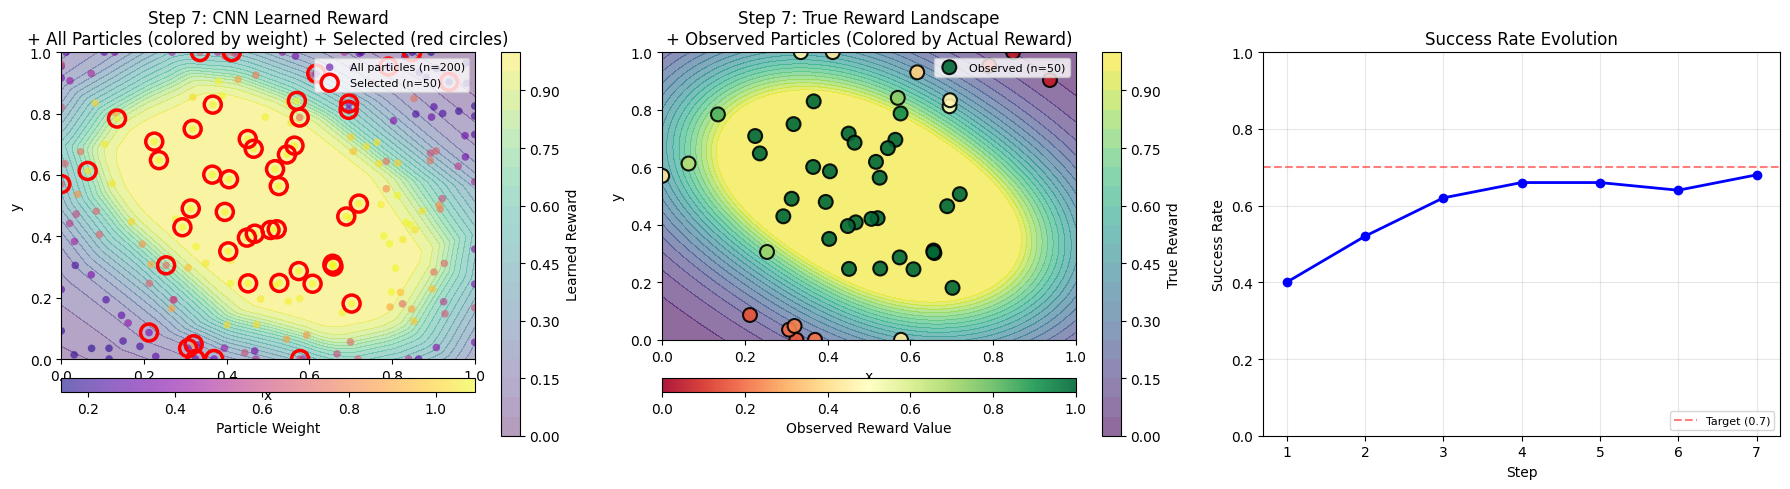

Step 7: Observed 50 particles | Avg Reward: 0.764 | Success: 34/50 (68.0%)
Step 7, Budget remaining: 150
  Epsilon=0.333 -> Selecting 33 top-k + 17 random particles
    Top-k weight range: [1.087, 1.090]
    Random weight range: [0.231, 1.085]
    All particles weight range: [0.136, 1.090]
  Training CNN on 50 new observations...


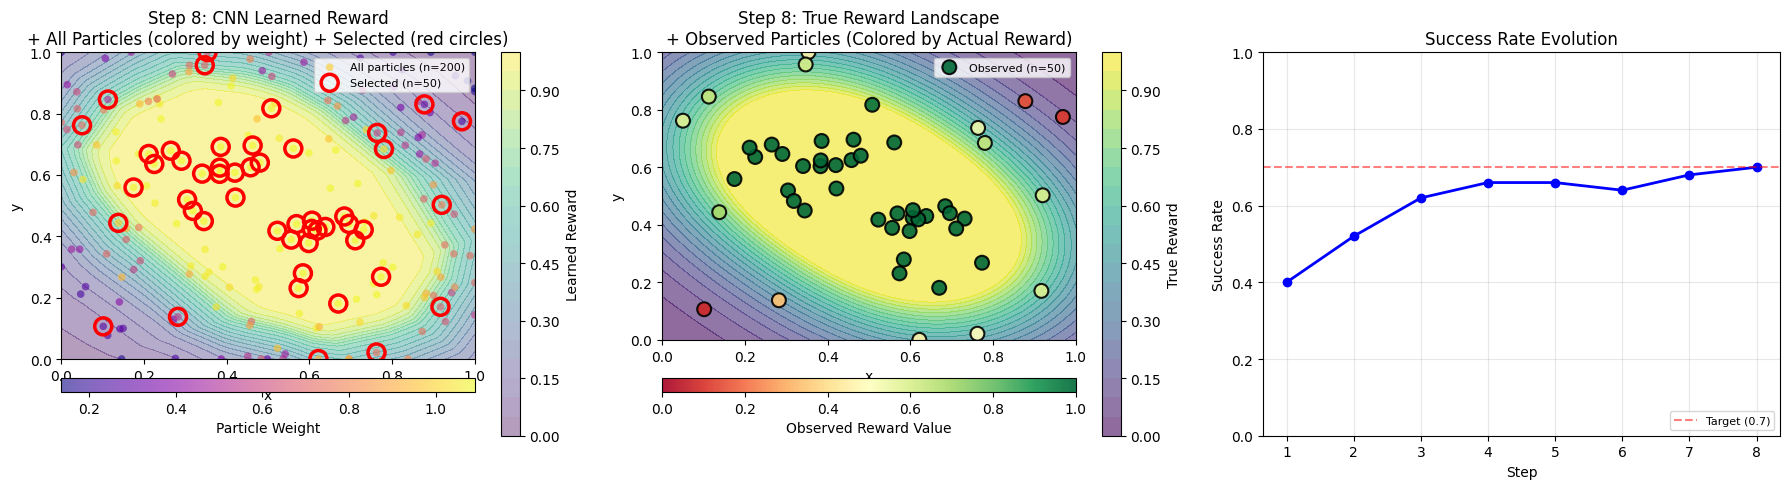

Step 8: Observed 50 particles | Avg Reward: 0.839 | Success: 35/50 (70.0%)
Step 8, Budget remaining: 100
  Epsilon=0.256 -> Selecting 37 top-k + 13 random particles
    Top-k weight range: [1.087, 1.090]
    Random weight range: [0.138, 1.087]
    All particles weight range: [0.129, 1.090]
  Training CNN on 50 new observations...


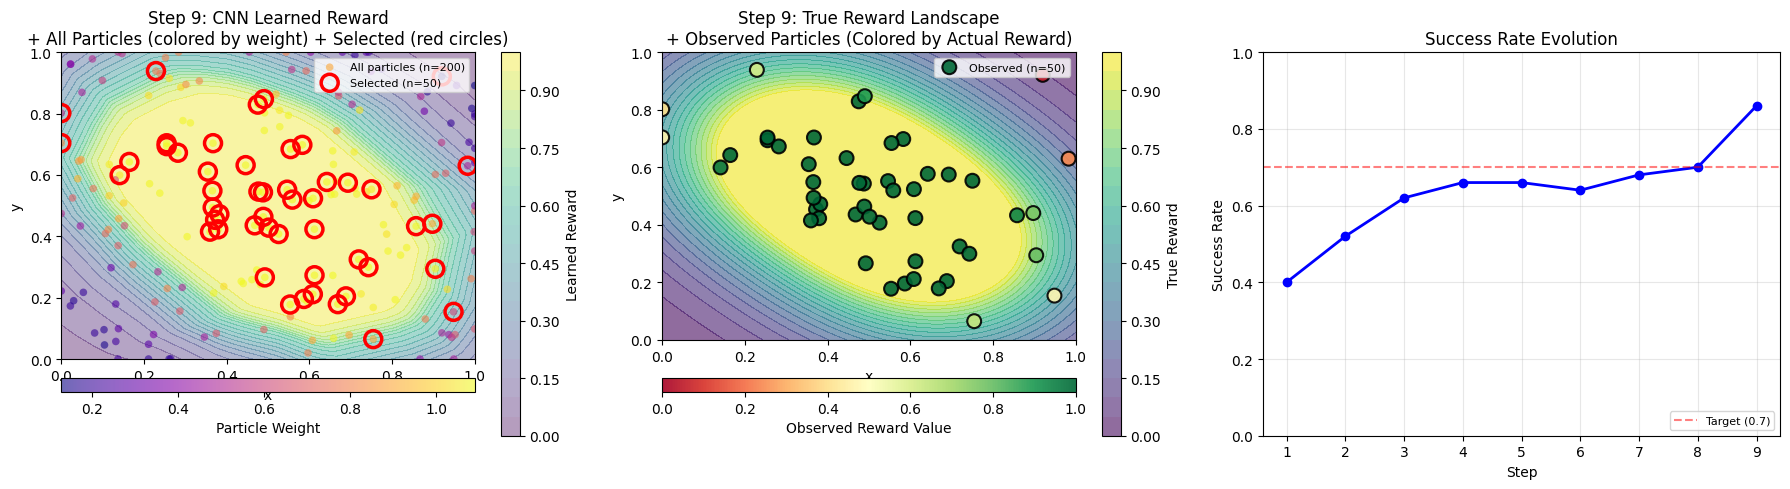

Step 9: Observed 50 particles | Avg Reward: 0.905 | Success: 43/50 (86.0%)
Step 9, Budget remaining: 50
  Epsilon=0.178 -> Selecting 41 top-k + 9 random particles
    Top-k weight range: [1.085, 1.090]
    Random weight range: [0.164, 1.082]
    All particles weight range: [0.130, 1.090]
  Training CNN on 50 new observations...


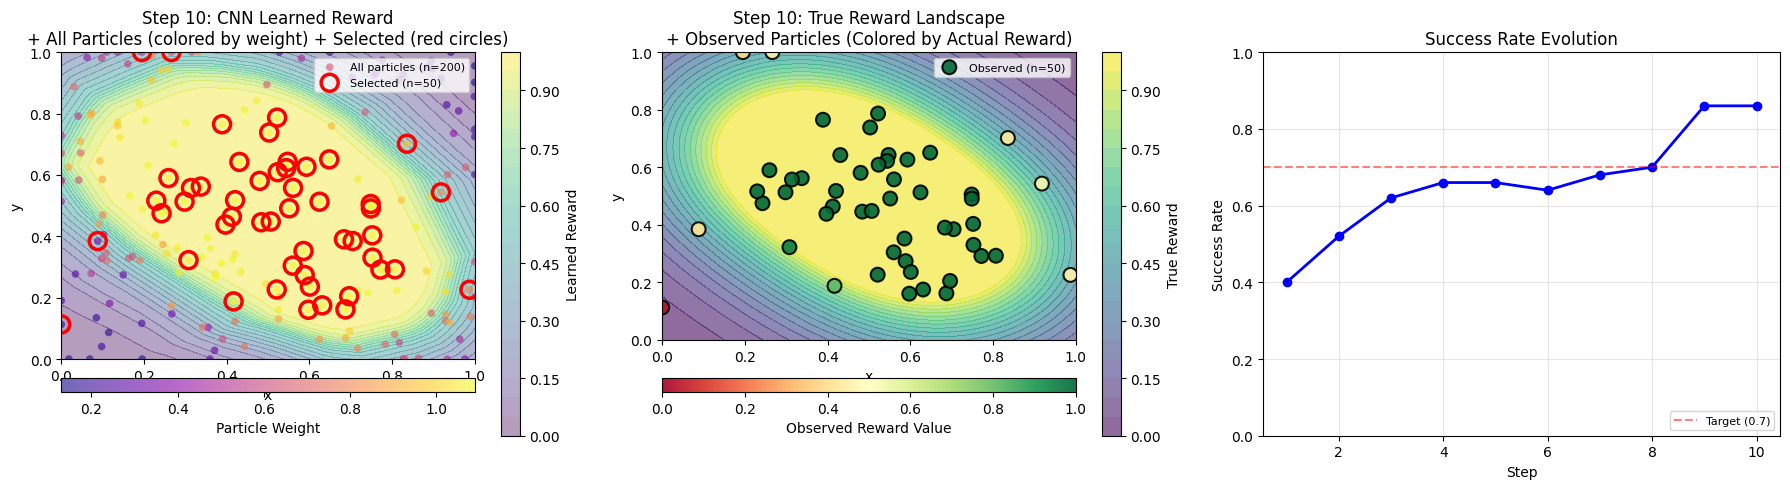

Step 10: Observed 50 particles | Avg Reward: 0.910 | Success: 43/50 (86.0%)

EPSILON-GREEDY VISUALIZATION FOR THREE PEAKS



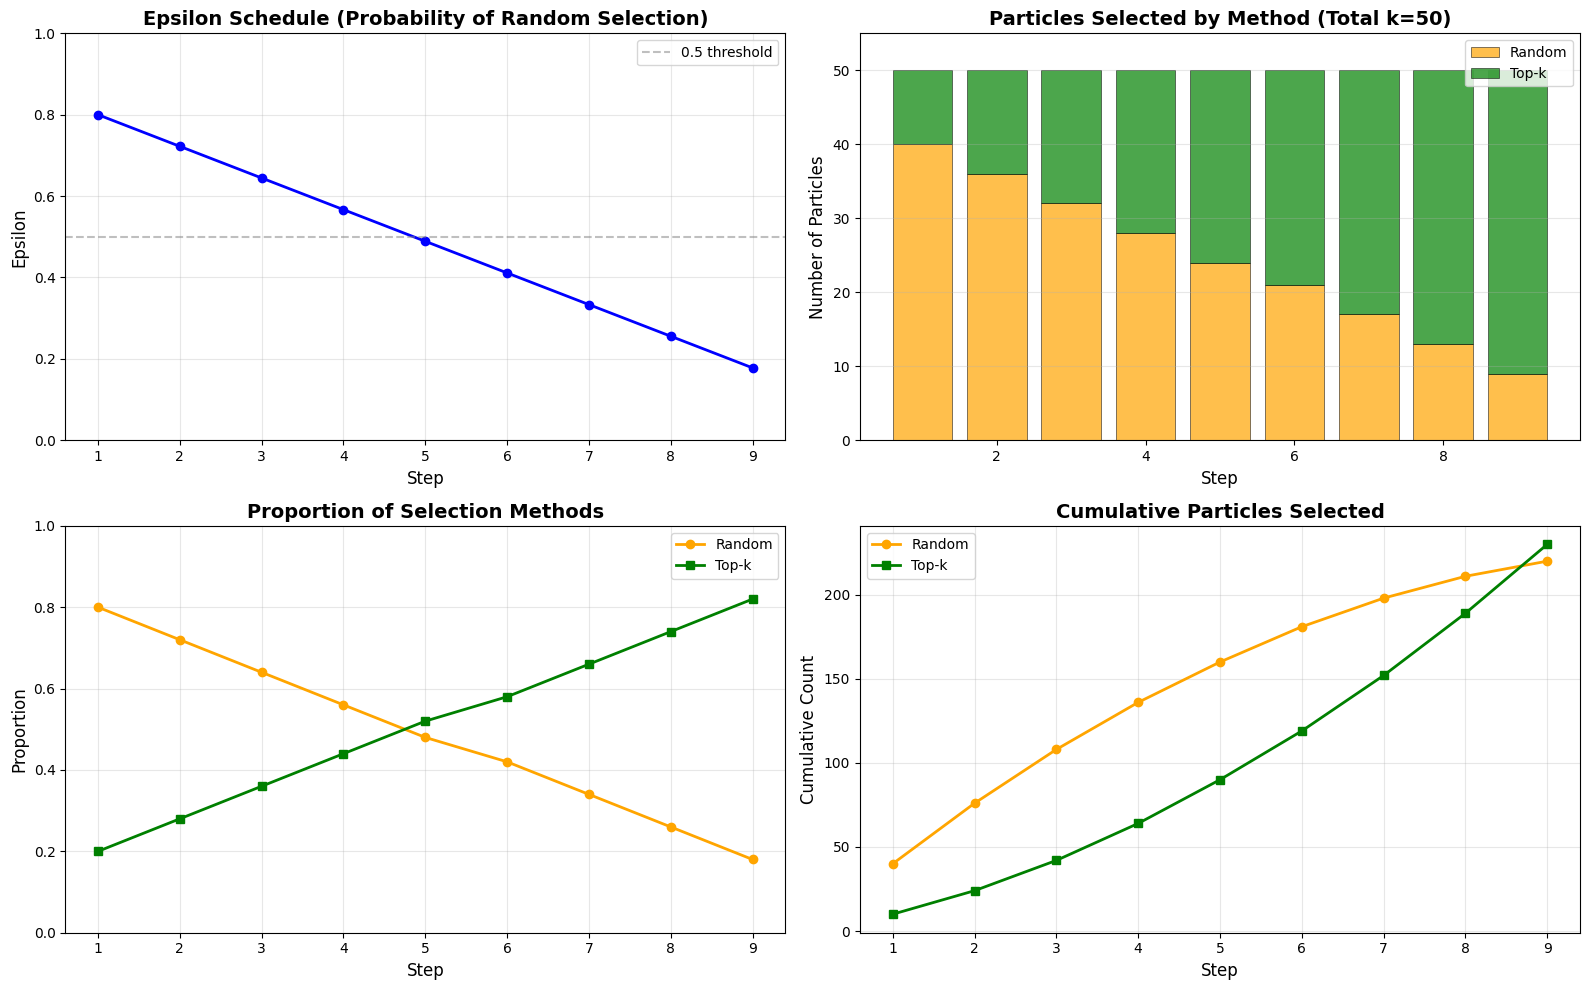


EPSILON-GREEDY SELECTION SUMMARY
Total steps (excluding cold start): 9
Total particles observed: 450
Particles selected RANDOMLY: 220 (48.9%)
Particles selected TOP-K: 230 (51.1%)

Epsilon range: [0.178, 0.800]
Final epsilon: 0.178
Average particles per step - Random: 24.4, Top-k: 25.6

  Using pre-trained neural network (continuing training)
Step 0 [COLD START], Budget remaining: 500


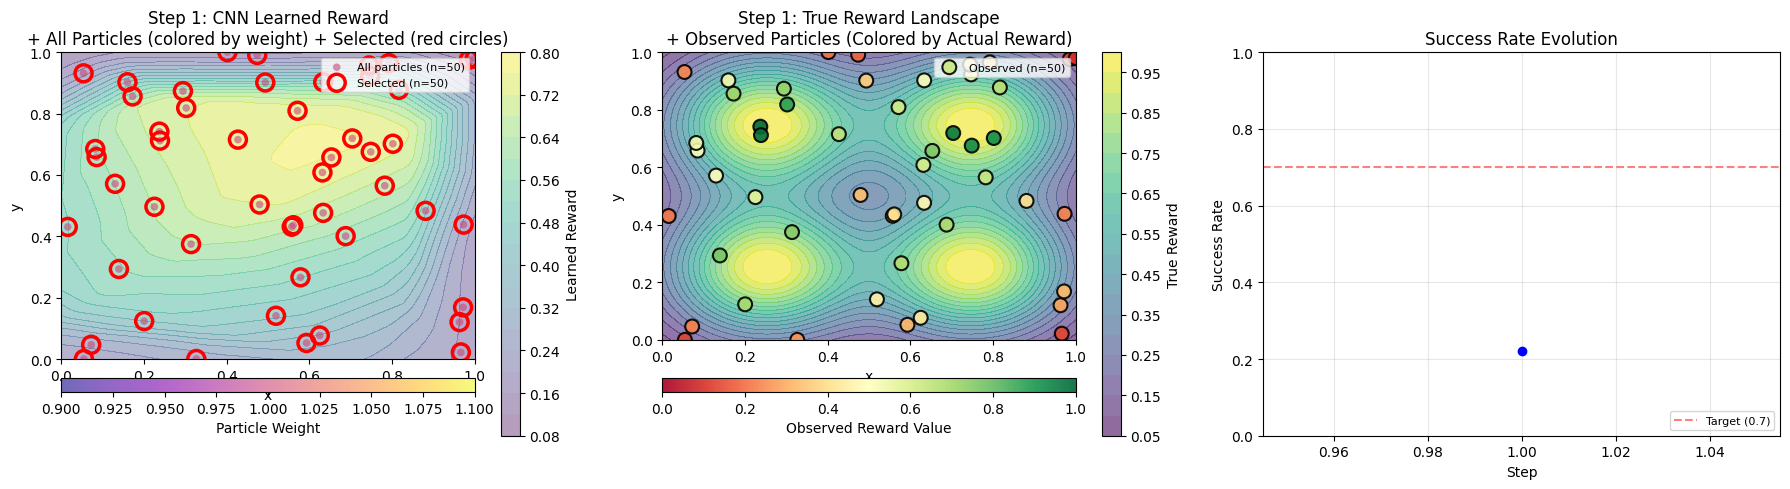

Step 1: Observed 50 particles | Avg Reward: 0.509 | Success: 11/50 (22.0%)
Step 1, Budget remaining: 450
  Epsilon=0.800 -> Selecting 10 top-k + 40 random particles
    Top-k weight range: [0.840, 0.854]
    Random weight range: [0.262, 0.835]
    All particles weight range: [0.229, 0.854]
  Training CNN on 50 new observations...


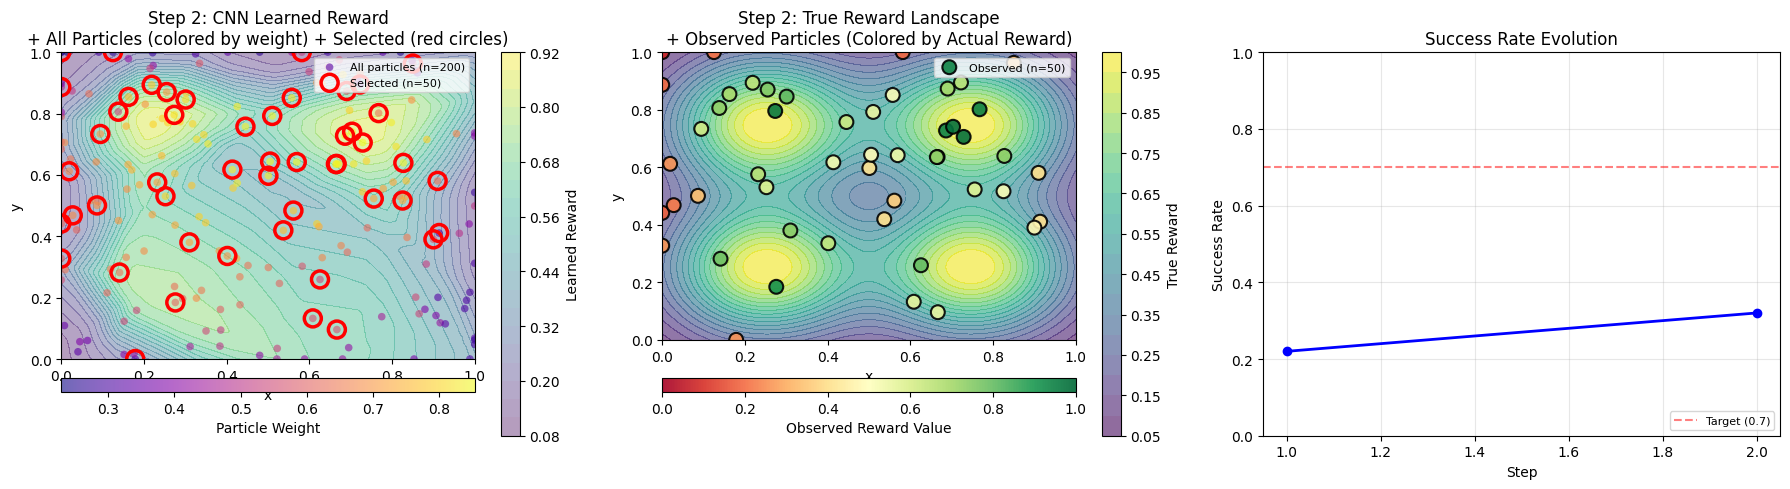

Step 2: Observed 50 particles | Avg Reward: 0.565 | Success: 16/50 (32.0%)
Step 2, Budget remaining: 400
  Epsilon=0.722 -> Selecting 14 top-k + 36 random particles
    Top-k weight range: [0.815, 0.945]
    Random weight range: [0.246, 0.787]
    All particles weight range: [0.246, 0.945]
  Training CNN on 50 new observations...


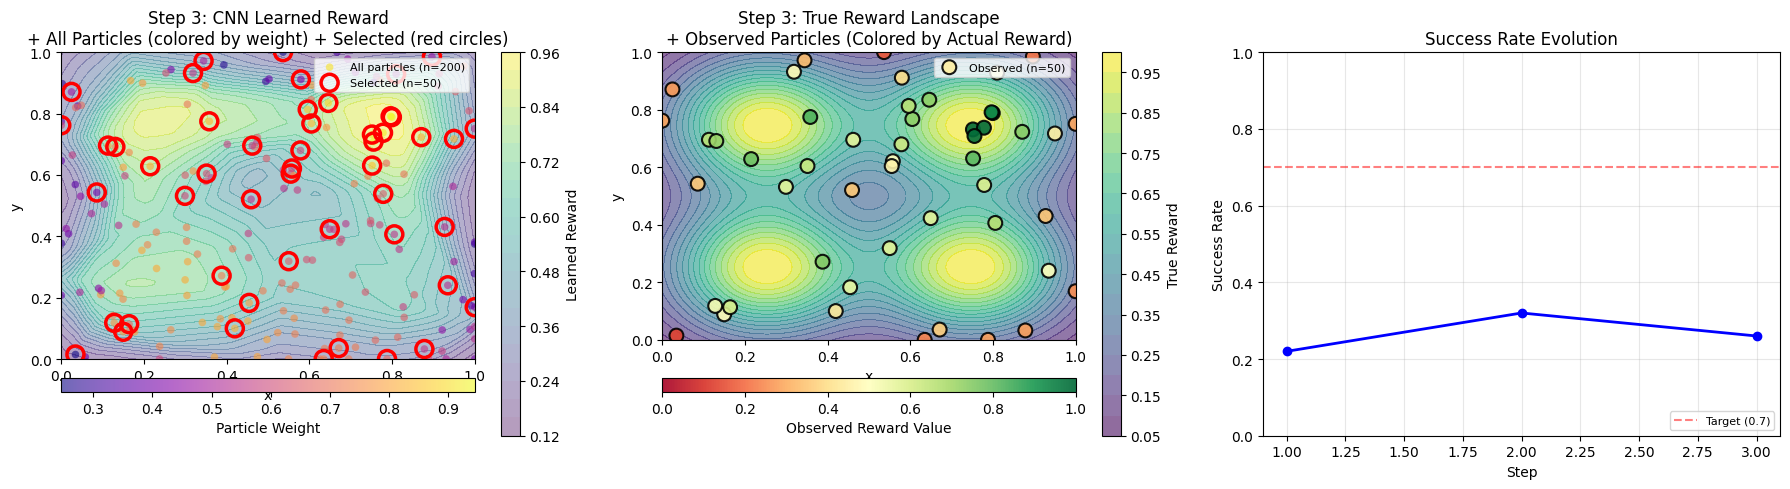

Step 3: Observed 50 particles | Avg Reward: 0.542 | Success: 13/50 (26.0%)
Step 3, Budget remaining: 350
  Epsilon=0.644 -> Selecting 18 top-k + 32 random particles
    Top-k weight range: [0.901, 1.021]
    Random weight range: [0.331, 0.839]
    All particles weight range: [0.284, 1.021]
  Training CNN on 50 new observations...


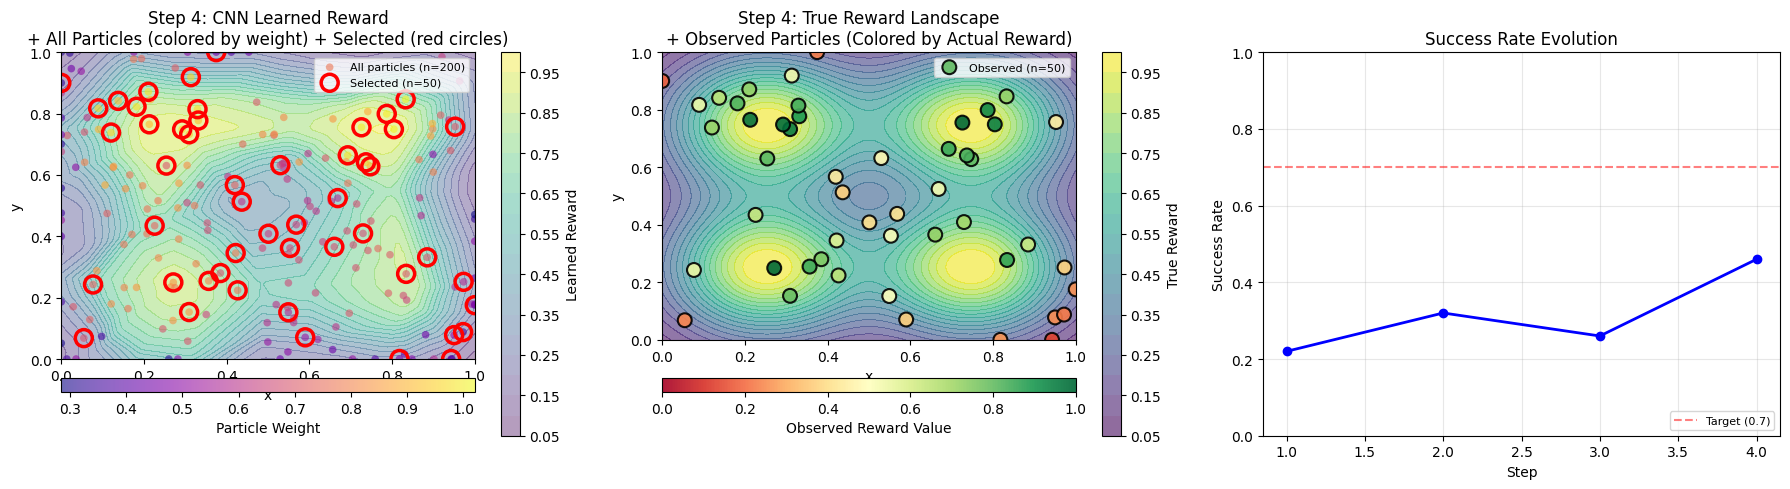

Step 4: Observed 50 particles | Avg Reward: 0.619 | Success: 23/50 (46.0%)
Step 4, Budget remaining: 300
  Epsilon=0.567 -> Selecting 22 top-k + 28 random particles
    Top-k weight range: [0.887, 1.026]
    Random weight range: [0.235, 0.883]
    All particles weight range: [0.235, 1.026]
  Training CNN on 50 new observations...


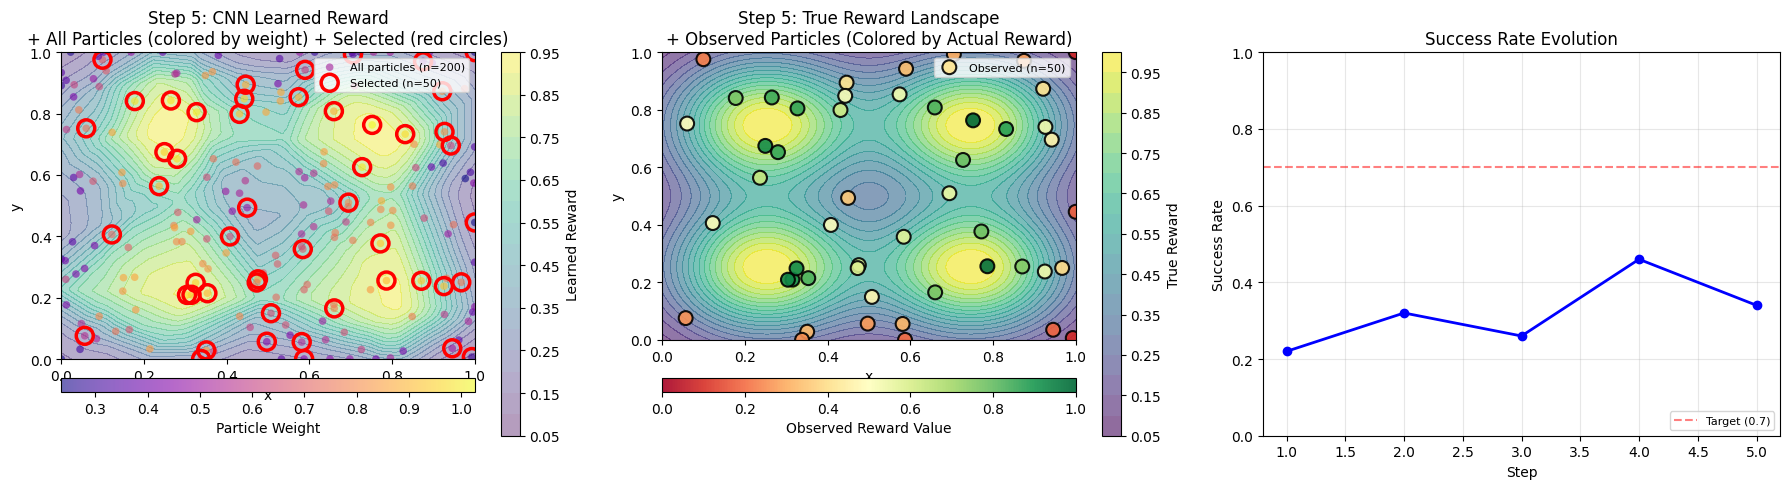

Step 5: Observed 50 particles | Avg Reward: 0.553 | Success: 17/50 (34.0%)
Step 5, Budget remaining: 250
  Epsilon=0.489 -> Selecting 26 top-k + 24 random particles
    Top-k weight range: [0.883, 1.000]
    Random weight range: [0.240, 0.870]
    All particles weight range: [0.240, 1.000]
  Training CNN on 50 new observations...


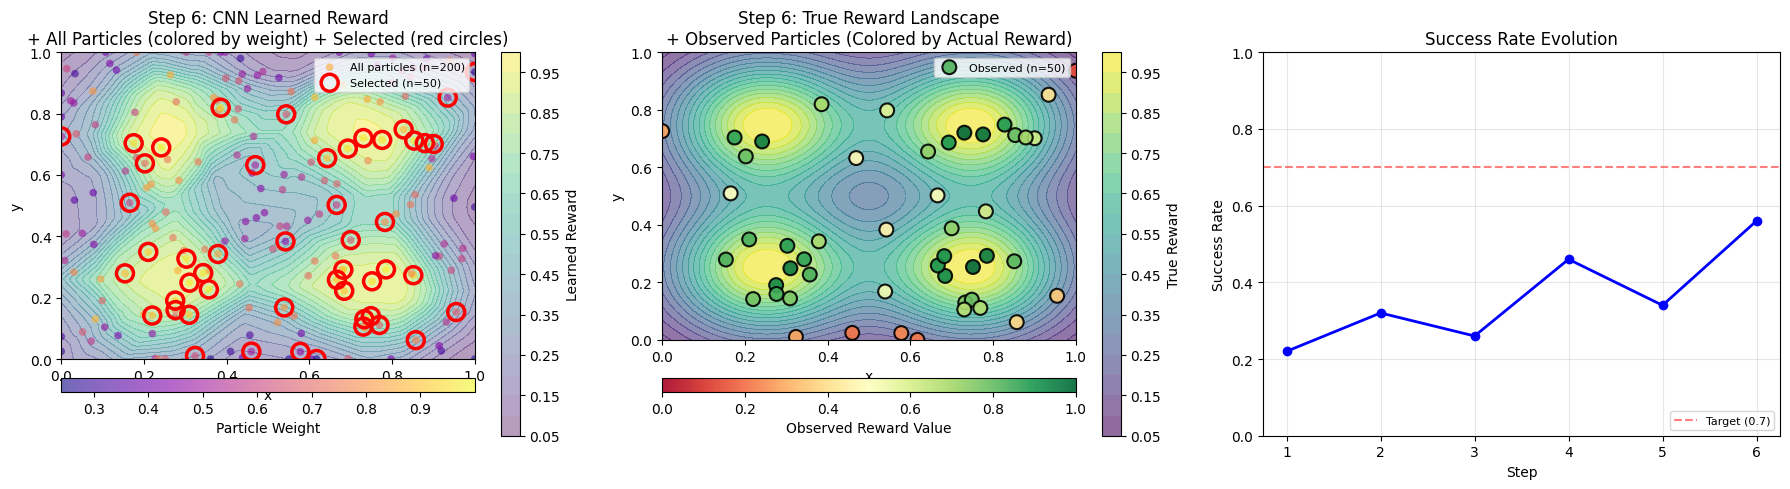

Step 6: Observed 50 particles | Avg Reward: 0.690 | Success: 28/50 (56.0%)
Step 6, Budget remaining: 200
  Epsilon=0.411 -> Selecting 29 top-k + 21 random particles
    Top-k weight range: [0.929, 1.034]
    Random weight range: [0.223, 0.870]
    All particles weight range: [0.206, 1.034]
  Training CNN on 50 new observations...


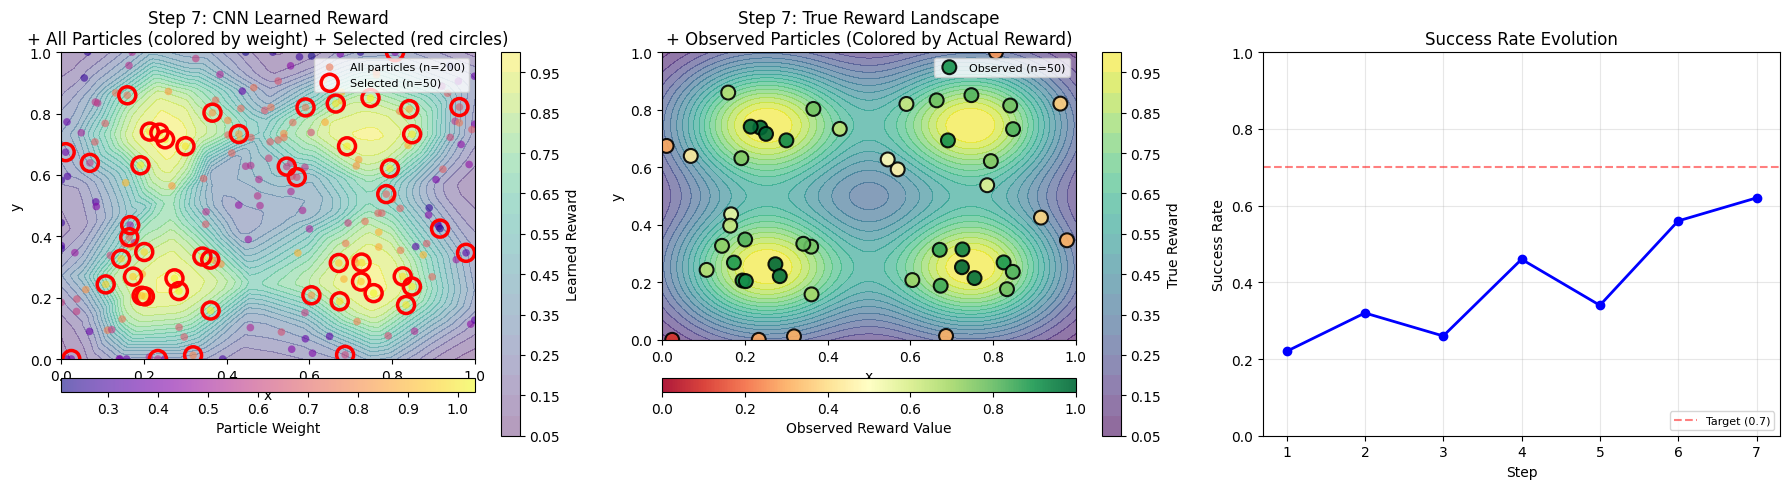

Step 7: Observed 50 particles | Avg Reward: 0.702 | Success: 31/50 (62.0%)
Step 7, Budget remaining: 150
  Epsilon=0.333 -> Selecting 33 top-k + 17 random particles
    Top-k weight range: [0.920, 1.060]
    Random weight range: [0.294, 0.822]
    All particles weight range: [0.204, 1.060]
  Training CNN on 50 new observations...


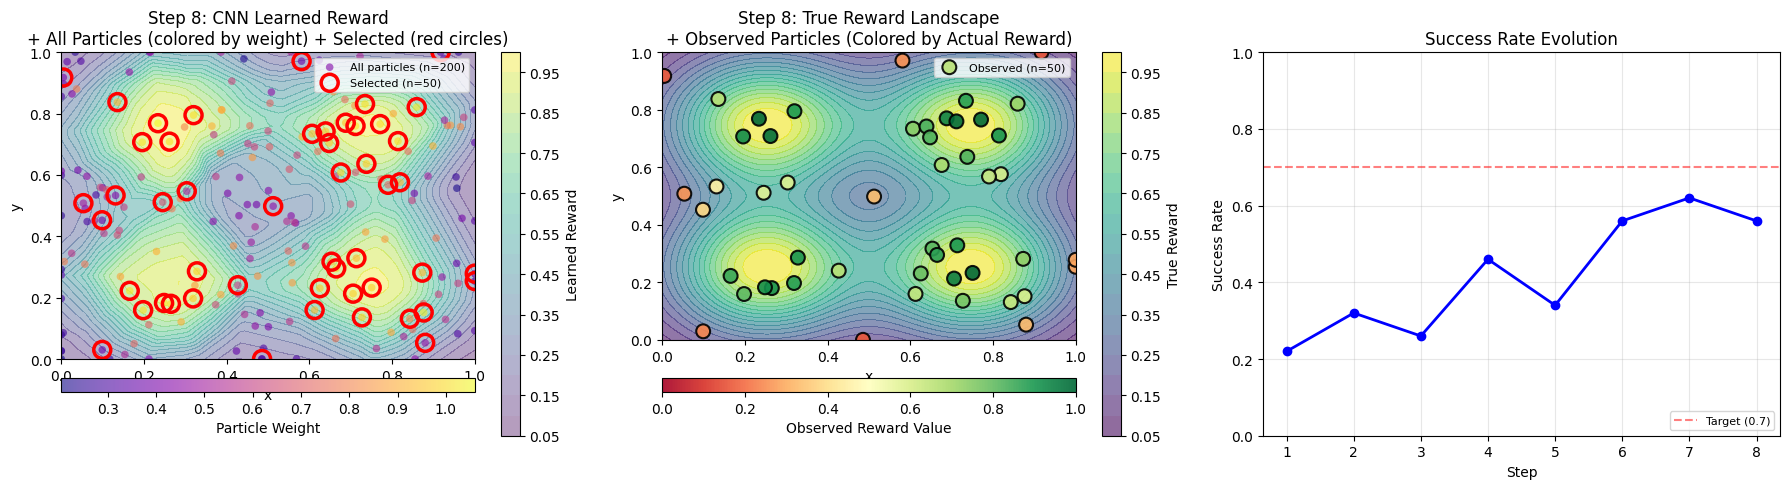

Step 8: Observed 50 particles | Avg Reward: 0.684 | Success: 28/50 (56.0%)
Step 8, Budget remaining: 100
  Epsilon=0.256 -> Selecting 37 top-k + 13 random particles
    Top-k weight range: [0.897, 1.064]
    Random weight range: [0.313, 0.876]
    All particles weight range: [0.211, 1.064]
  Training CNN on 50 new observations...


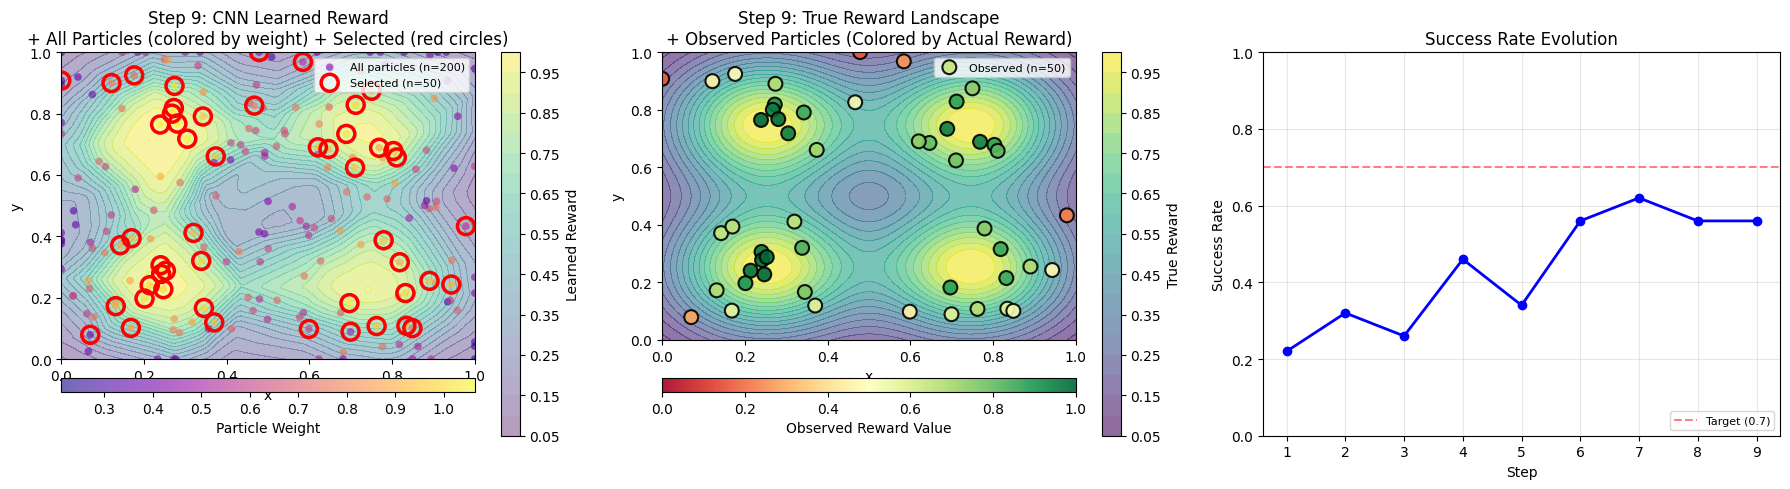

Step 9: Observed 50 particles | Avg Reward: 0.713 | Success: 28/50 (56.0%)
Step 9, Budget remaining: 50
  Epsilon=0.178 -> Selecting 41 top-k + 9 random particles
    Top-k weight range: [0.935, 1.074]
    Random weight range: [0.270, 0.779]
    All particles weight range: [0.206, 1.074]
  Training CNN on 50 new observations...


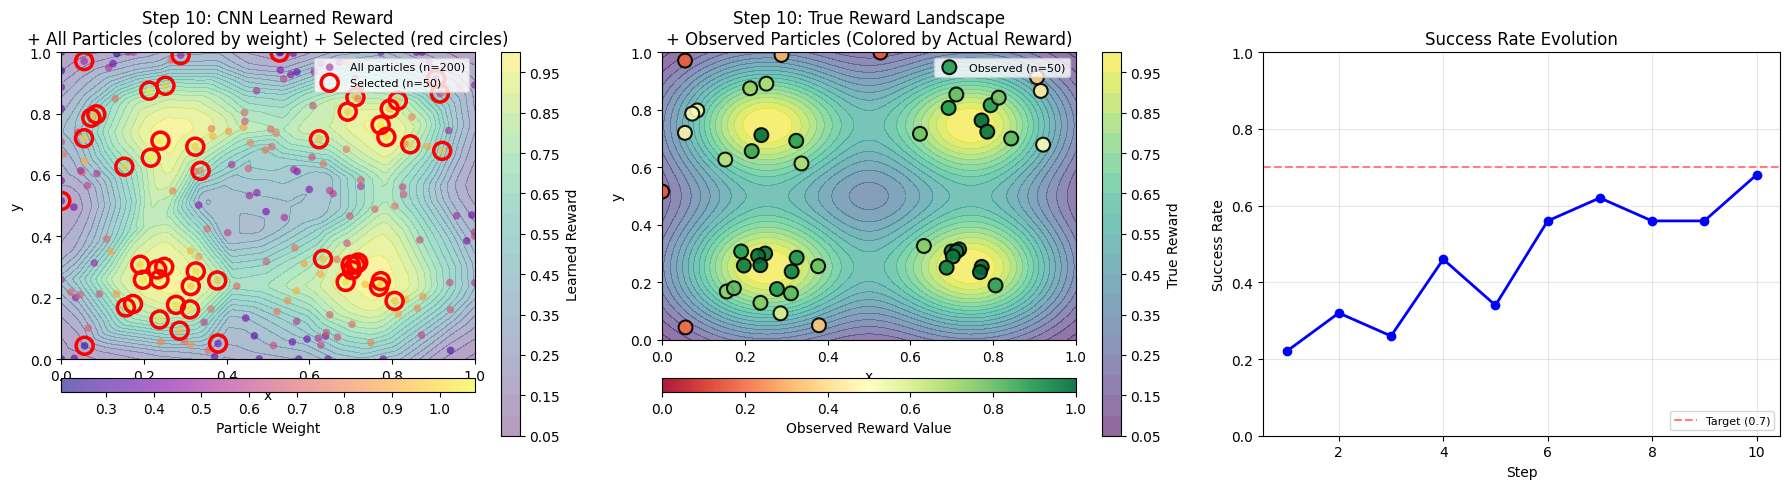

Step 10: Observed 50 particles | Avg Reward: 0.740 | Success: 34/50 (68.0%)

EPSILON-GREEDY VISUALIZATION FOR FOUR OPTIMA



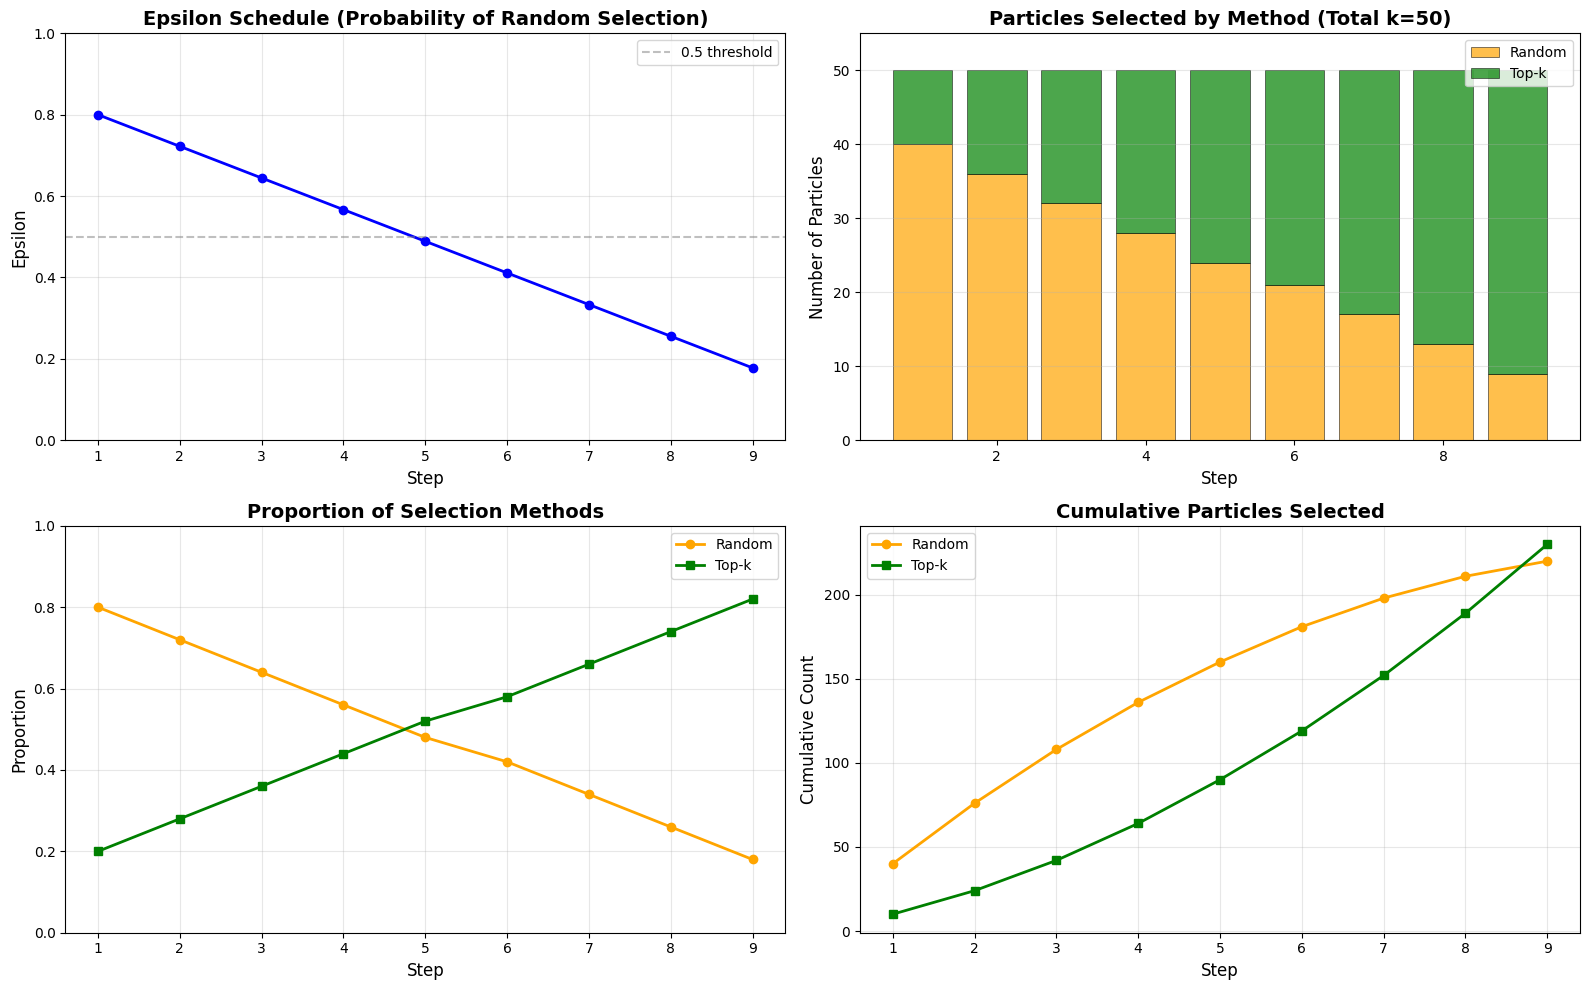


EPSILON-GREEDY SELECTION SUMMARY
Total steps (excluding cold start): 9
Total particles observed: 450
Particles selected RANDOMLY: 220 (48.9%)
Particles selected TOP-K: 230 (51.1%)

Epsilon range: [0.178, 0.800]
Final epsilon: 0.178
Average particles per step - Random: 24.4, Top-k: 25.6



In [9]:
# Experiment parameters
k_observe = 50  # Number of particles to observe per step
B = 500  # Total budget (total observations allowed)
n_particles = 200  # Number of particles to generate per FKC step

# Define reward functions
reward_function_3peaks = create_reward_landscape
reward_function_4optima = create_four_optima_reward_landscape

# Run 1: Three Peaks
results_3peaks = budget_constrained_diffusion(
    k_observe, B, n_particles, 
    reward_fn=reward_function_3peaks
)

(all_particles_3peaks, all_weights_3peaks, all_observed_particles_3peaks, 
 all_observed_rewards_3peaks, success_rates_3peaks, 
 trained_network, trained_params, trained_opt_state, 
 epsilon_history_3peaks, selection_method_history_3peaks,
 num_random_3peaks, num_topk_3peaks) = results_3peaks

# Visualize epsilon-greedy behavior
print("\n" + "="*80)
print("EPSILON-GREEDY VISUALIZATION FOR THREE PEAKS")
print("="*80 + "\n")
visualize_epsilon_and_selection(epsilon_history_3peaks, selection_method_history_3peaks, 
                               num_random_3peaks, num_topk_3peaks, k_observe)

# Run 2: Four Optima
results_4optima = budget_constrained_diffusion(
    k_observe, B, n_particles, 
    reward_fn=reward_function_4optima,
    network=trained_network,
    network_params=trained_params,
    opt_state=trained_opt_state
)

(all_particles_4optima, all_weights_4optima, all_observed_particles_4optima, 
 all_observed_rewards_4optima, success_rates_4optima, 
 final_network, final_params, final_opt_state, 
 epsilon_history_4optima, selection_method_history_4optima,
 num_random_4optima, num_topk_4optima) = results_4optima

# Visualize epsilon-greedy behavior
print("\n" + "="*80)
print("EPSILON-GREEDY VISUALIZATION FOR FOUR OPTIMA")
print("="*80 + "\n")
visualize_epsilon_and_selection(epsilon_history_4optima, selection_method_history_4optima, 
                               num_random_4optima, num_topk_4optima, k_observe)